Используемые библиотеки:

In [1]:
#Базовая обработка данных:
import pandas as pd
import numpy as np
import json
import re
#Визуализация данных:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style='white', context='notebook', palette='deep')
%config InlineBackend.figure_format = 'retina' 
%matplotlib inline
#Статистический анализ и преобразование данных:
from scipy.stats import skew
from scipy import stats
from scipy.stats import pearsonr
from scipy.stats import norm
#Машинное обучение:
import xgboost as xgb
from sklearn.linear_model import LinearRegression,LassoCV, Ridge, LassoLarsCV,ElasticNetCV
from sklearn.model_selection import GridSearchCV, cross_val_score, learning_curve, train_test_split
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, Normalizer, RobustScaler
from sklearn.metrics import mean_squared_error, r2_score
#Вспомогательные библиотеки:
import warnings
warnings.filterwarnings('ignore')

#Работа выполнена на Python версии 3.12.6

Часть 1. 

Знакомство с данными и предобработка числовых признаков.

In [2]:
#Прежде всего нужно загрузить данные из файла:
data = pd.read_csv('data/house_data.csv')
data.head()

,status,private pool,propertyType,street,baths,homeFacts,fireplace,city,schools,sqft,zipcode,beds,state,stories,mls-id,PrivatePool,MlsId,target
0,Active,NaN,Single Family Home,240 Heather Ln,3.5,"{'atAGlanceFacts': [{'factValue': '2019', 'fac...",Gas Logs,Southern Pines,"[{'rating': ['4', '4', '7', 'NR', '4', '7', 'N...",2900,28387,4,NC,NaN,NaN,NaN,611019,"$418,000"
1,for sale,NaN,single-family home,12911 E Heroy Ave,3 Baths,"{'atAGlanceFacts': [{'factValue': '2019', 'fac...",NaN,Spokane Valley,"[{'rating': ['4/10', 'None/10', '4/10'], 'data...","1,947 sqft",99216,3 Beds,WA,2.0,NaN,NaN,201916904,"$310,000"
2,for sale,NaN,single-family home,2005 Westridge Rd,2 Baths,"{'atAGlanceFacts': [{'factValue': '1961', 'fac...",yes,Los Angeles,"[{'rating': ['8/10', '4/10', '8/10'], 'data': ...","3,000 sqft",90049,3 Beds,CA,1.0,NaN,yes,FR19221027,"$2,895,000"
3,for sale,NaN,single-family home,4311 Livingston Ave,8 Baths,"{'atAGlanceFacts': [{'factValue': '2006', 'fac...",yes,Dallas,"[{'rating': ['9/10', '9/10', '10/10', '9/10'],...","6,457 sqft",75205,5 Beds,TX,3.0,NaN,NaN,14191809,"$2,395,000"
4,for sale,NaN,lot/land,1524 Kiscoe St,NaN,"{'atAGlanceFacts': [{'factValue': '', 'factLab...",NaN,Palm Bay,"[{'rating': ['4/10', '5/10', '5/10'], 'data': ...",NaN,32908,NaN,FL,NaN,NaN,NaN,861745,"$5,000"


Сразу же, без выполнения всякого анализа, можно увидеть сразу три бесполезных для моделирования признака:
почтовый индекс - zipcode; и две (скорее всего, дублирующие друг друга) версии идентификатора объектов недвижимости,
используемого риэлторскими агентствами в США (Multiple Listing Service) - mls-id и MlsId. Убираем их из рабочего датасета (сделав их резервные копии в отдельной переменной).

In [3]:
identificators = data[['zipcode', 'mls-id', 'MlsId']]
data = data.drop(labels=['zipcode', 'mls-id', 'MlsId'], axis=1)

После удаления идентификаторов исходный датасет содержит 4 количественных признака (baths, beds, stories, и sqft - количество ванных комнат, кроватей, и этажей в доме соответственно, плюс его площадь), 8 качественных признаков, и два признака, по-видимому представляющие из себя JSON-объекты, а также целевую переменную target (стоимость дома или участка, по которой его удалось продать). Однако из output'а выше сразу же видно, что целевая переменная и признаки baths, beds и sqft сейчас находятся в виде строк, а не чисел. Проверим, так ли это и для признака stories: 

In [5]:
print('The data in the stories column is of {} type'.format(data['stories'].dtype))

The data in the stories column is of object type


Итак, все числовые переменные сейчас находятся в объектном (строковом) виде, при этом кроме цифр в строках содержатся "лишние" символы. Напишем код для приведения всех этих объектов к числовому виду и обернём его в функцию. Обратите внимание, что просто удалять все нечисловые символы нельзя - нужно обязательно оставить десятичную точку, которая присутствует в значениях колонки baths (дробные количества ванных комнат используются для обозначения полноты комплектации комнаты: так например, душевая кабинка счиается за 0.25 ванной комнаты; комната, содержащая только унитаз и раковину - за 0.5 ванной комнаты и т.д.).

In [6]:
 def get_numeric(string):
    try:
        result = re.sub(r"[^0-9|.]", "", string)
        return float(result)
    except:#Это нужно для обработки пропущенных значений
        return np.nan
#Тестовый пуск функции
print(get_numeric('$310,000'))
print(get_numeric('2.5 baths'))

310000.0
2.5


In [7]:
for column in ['target', 'baths', 'beds', 'sqft', 'stories']:
    data.loc[:, column] = data[column].apply(get_numeric)
    data[column] = data[column].astype(float)

Видно также, что какая-то числовая информация содержится в обоих JSON-признаках. Посмотрим на их структуру, чтобы разобраться подробнее:

In [8]:
print(data['homeFacts'][0])
print(data['schools'][0])

{'atAGlanceFacts': [{'factValue': '2019', 'factLabel': 'Year built'}, {'factValue': '', 'factLabel': 'Remodeled year'}, {'factValue': 'Central A/C, Heat Pump', 'factLabel': 'Heating'}, {'factValue': '', 'factLabel': 'Cooling'}, {'factValue': '', 'factLabel': 'Parking'}, {'factValue': None, 'factLabel': 'lotsize'}, {'factValue': '$144', 'factLabel': 'Price/sqft'}]}
[{'rating': ['4', '4', '7', 'NR', '4', '7', 'NR', 'NR'], 'data': {'Distance': ['2.7 mi', '3.6 mi', '5.1 mi', '4.0 mi', '10.5 mi', '12.6 mi', '2.7 mi', '3.1 mi'], 'Grades': ['3–5', '6–8', '9–12', 'PK–2', '6–8', '9–12', 'PK–5', 'K–12']}, 'name': ['Southern Pines Elementary School', 'Southern Middle School', 'Pinecrest High School', 'Southern Pines Primary School', "Crain's Creek Middle School", 'Union Pines High School', 'Episcopal Day Private School', 'Calvary Christian Private School']}]


*Здесь обзор структуры объектов*

In [9]:
#Создадим вспомогательную функцию для удобного перевода JSON-литералов в удобный для обработки вид
def json_string_formatter(json_string):
    json_string = json_string.replace('\'s', '')
    json_string = json_string.replace('\'', '"')
    json_string = json_string.replace('\\', '')
    json_string = json_string.replace('\"\"', 'null')
    json_string = json_string.replace('None', 'null')
    return json_string 

Создадим функцию для извлечения из JSON-объектов, находящихся в колонке homeFacts, значений произвольного признака, представленного в виде одной из JSON-записей внутри JSON-массива "atAGlanceFacts". Сначала нужно идентифицировать признак-запись по его имени (значению ключа factLabel), а затем извлечь его собственное значение по ключу factValue. Обратите внимание, что имя нужного нам признака находится во внешней для функции переменной column_name. Это позволит нам легко использовать функцию в цикле, чтобы извлечь сразу несколько признаков.

In [10]:
def home_facts_parser(json_string):
    try:
        json_string = json_string_formatter(json_string)
        json_data = json.loads(json_string)['atAGlanceFacts']

        for item in json_data:
            if item['factLabel'] == column_name:
                return item['factValue']
    except:
        return np.nan 
#Тестовый пуск функции   
column_name = 'Year built'
home_facts_parser(data['homeFacts'][0])

'2019'

Для безопасности данных пока будем извлекать признаки из JSON-колонок в отдельную таблицу. Извлечём информацию о годах постройки и последнего ремонта дома, а также о "lotsize" - предположительно, размера всего участка (размер жилой площади у нас уже есть в колонке sqft). Признак Price/sqft нам не нужен, так как напрямую зависит от целевой переменной и привёл бы к утечке данных при попытках использовать его в создании модели.

In [1]:
data_from_json = pd.DataFrame()

for column in ['Year built', 'Remodeled year', 'lotsize']:
    column_name = column
    data_from_json.loc[:, column] = data['homeFacts'].apply(home_facts_parser)

NameError: name 'pd' is not defined

Признак schools слишком сложен, так как содержит информацию сразу о нескольких ближайших школах, каждая - с несколькими характеристиками, и при этом признак ещё и имеет нелинейную структуру. Целесообразно будет кардинально упростить его, учитывая информацию только о самой ближайшей к дому школе. Создадим функции для извлечения информации о расстоянии до ближайшей школы и о её рейтинге.

In [12]:
def get_nearest_school_distance(json_string):
    try:
       json_string = json_string_formatter(json_string)
       json_data = json.loads(json_string)[0]

       distance_list = pd.Series(json_data['data']['Distance'])
       distance_list = distance_list.apply(lambda x: float(x[:-3]))
       return distance_list.min()
    except:
        return np.nan 
    
def get_nearest_school_rating(json_string):
    try:
        json_string = json_string_formatter(json_string)
        json_data = json.loads(json_string)[0]

        distance_list = pd.Series(json_data['data']['Distance'])
        distance_list = distance_list.apply(lambda x: float(x[:-3]))
        ratings_list = json_data['rating']

        for i in range(len(distance_list)):
            if distance_list[i]==distance_list.min():
                return ratings_list[i]
    except:
        return np.nan
#Тестовый пуск функции
print(get_nearest_school_distance(data['schools'][0]))
print(get_nearest_school_rating(data['schools'][0]))

2.7
4


In [13]:
data_from_json['nearest_school_distance'] = data['schools'].apply(get_nearest_school_distance)
data_from_json['nearest_school_rating'] = data['schools'].apply(get_nearest_school_rating)
data_from_json.head()#Посмотрим, что у нас получилось.

,Year built,Remodeled year,lotsize,nearest_school_distance,nearest_school_rating
0,2019,None,None,2.7,4
1,2019,None,5828 sqft,1.0,4/10
2,1961,1967,"8,626 sqft",1.1,8/10
3,2006,2006,"8,220 sqft",0.0,9/10
4,None,None,"10,019 sqft",3.0,5/10


In [14]:
data_from_json.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 377185 entries, 0 to 377184
Data columns (total 5 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Year built               314479 non-null  object 
 1   Remodeled year           151075 non-null  object 
 2   lotsize                  315399 non-null  object 
 3   nearest_school_distance  367840 non-null  float64
 4   nearest_school_rating    367840 non-null  object 
dtypes: float64(1), object(4)
memory usage: 14.4+ MB


В первую очередь нужно понять, что делать с огромным (более половины) от общего количества значений числом пропусков в колонке Remodled year.
Можно предположить, что если у дома отсутствует информация о последнем ремонте, значит, он скорее всего вообще никогда не ремонтировался.
Такое положение дел можно оформить как формальный "ремонт" дома ("ремонт из состояния несуществования"), совпадающий с его строительстом.
Подставим, где это возможно, в пропуски в колонке Remodeled year соответствующие им значения из колонки Year built.

In [16]:
data_from_json['Remodeled year'] = data_from_json['Remodeled year'].fillna(value=data_from_json['Year built'])
data_from_json.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 377185 entries, 0 to 377184
Data columns (total 5 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Year built               314479 non-null  object 
 1   Remodeled year           315891 non-null  object 
 2   lotsize                  315399 non-null  object 
 3   nearest_school_distance  367840 non-null  float64
 4   nearest_school_rating    367840 non-null  object 
dtypes: float64(1), object(4)
memory usage: 14.4+ MB


Теперь полученные признаки также нужно преобразовать в числовой тип данных из объектного(кроме nearest_school_distance, который уже был приведён к нему нашей функцией-парсером). Для большинства из них можно снова применить ранее созданную get_numeric:

In [17]:
#Можно уже начать переносить признаки в основной датафрейм:
data['Year built'] = data_from_json['Year built'].apply(get_numeric)
data['Remodeled year'] = data_from_json['Remodeled year'].apply(get_numeric)
data['lotsize'] = data_from_json['lotsize'].apply(get_numeric)

Но для колонки с рейтингом школ get_numeric не подойдёт - нужно создать новый парсер, который бы игнорировал не несущие информацию "/10" на конце рейтингов.

In [18]:
def parse_school_rating(string):
    try:
        string = string.split(sep='/')[0]
        if string.isnumeric():
            return int(string)
        else:
            return np.nan
    except:#Нужно для обработки пропущенных значений.
        return np.nan
#Тестовый пуск функции:
parse_school_rating('7/10')

7

Теперь все количественные признаки из JSON-колонок "распакованы" в рабочий датафрейм.

In [22]:
data['nearest_school_rating'] = data_from_json['nearest_school_rating'].apply(parse_school_rating)
data['nearest_school_distance'] = data_from_json['nearest_school_distance']
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 374668 entries, 0 to 377184
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   status                   335412 non-null  object 
 1   private pool             4150 non-null    object 
 2   propertyType             340114 non-null  object 
 3   street                   374668 non-null  object 
 4   baths                    267837 non-null  float64
 5   homeFacts                374668 non-null  object 
 6   fireplace                102521 non-null  object 
 7   city                     374668 non-null  object 
 8   schools                  374668 non-null  object 
 9   sqft                     333737 non-null  float64
 10  beds                     266452 non-null  float64
 11  state                    374668 non-null  object 
 12  stories                  212817 non-null  float64
 13  PrivatePool              40121 non-null   object 
 14  target   

Пропуски есть и в целевой переменной, их необходимо сразу же удалить. Заодно можно удалить и ничтожно малое количество пропусков в колонках city и street, чтобы не волноваться о них в дальнейшем.

In [20]:
data = data.dropna(subset=['target', 'city', 'street'], axis=0)

Теперь посмотрим на описательные статистики всех полученных нами количественных признаков:

In [23]:
features = {}
for feature in ['baths', 'beds', 'stories', 'sqft', 'Year built', 'Remodeled year', 
                'lotsize', 'nearest_school_distance', 'nearest_school_rating', 'target']:
    features[feature] = data[feature].describe()

features_descr = pd.DataFrame(features)

features_descr

,baths,beds,stories,sqft,Year built,Remodeled year,lotsize,nearest_school_distance,nearest_school_rating,target
count,2.678370e+05,266452.000000,212817.000000,3.337370e+05,3.110950e+05,3.125180e+05,2.513280e+05,365406.000000,341391.000000,3.746680e+05
mean,6.343871e+02,34.075494,1.949472,6.648119e+03,3.602106e+06,3.585715e+06,4.443724e+04,1.142416,5.279381,6.447692e+05
std,2.280889e+05,470.189475,5.175903,1.588662e+06,1.419870e+09,1.416634e+09,5.786227e+06,5.401830,2.401481,1.841509e+06
min,0.000000e+00,0.000000,0.000000,0.000000e+00,1.000000e+00,0.000000e+00,2.300000e-01,0.000000,1.000000,1.000000e+00
25%,2.000000e+00,3.000000,1.000000,1.242000e+03,1.957000e+03,1.964000e+03,1.510000e+00,0.300000,3.000000,1.869900e+05
50%,2.500000e+00,3.000000,2.000000,1.800000e+03,1.985000e+03,1.990000e+03,4.552000e+03,0.600000,5.000000,3.200000e+05
75%,3.000000e+00,4.000000,2.000000,2.588000e+03,2.007000e+03,2.008000e+03,7.840000e+03,1.300000,7.000000,5.820000e+05
max,1.161161e+08,10881.000000,1234.000000,7.959794e+08,5.599906e+11,5.599906e+11,2.147484e+09,1590.300000,10.000000,1.950000e+08


Пока что всё, что можно понять из статистики - это то, что во всех количественных признаках имеются очень большие выбросы (например, значение в 116 миллионов ванных комнат), которые должны кардинально затруднять дальнейшую работу с этими признаками, и от которых нужно избавиться как можно скорее. Этим мы займёмся на третьем этапе работы, сразу же после завершения предобработки категориальных признаков.

Этап 2. Предобработка категориальных признаков.

Сначала заметим, что в датасете присутствовало два разных признака, описывающих одно и то же - "private pool" и "PrivatePool", что скорее всего является следствием плохо организованного сбора данных. Можно обьединить эти два признака, заполнив пропуски в одном из них значениями из второго:

In [25]:
data['pool'] = data['private pool'].fillna(value=data['PrivatePool'])
data = data.drop(labels=['private pool', 'PrivatePool'], axis=1)
value = (sum(data['pool'].isna()) / data.shape[0]) * 100
print('Now there are {}% of missing values in the pool data'.format(round(value, 1)))

Now there are 88.2% of missing values in the pool data


Даже после обьединения почти 90% всех значений пропущены. В лучшем случае это знак того, что пропуском при сборе данных обозначалось отстутствие бассейна. В худшем случае - признак придётся удалить. Чтобы понять, придётся ли избавляться от признака или нет, посмотрим, какие значения он принимает:

In [26]:
print(data['pool'].unique())

[nan 'yes' 'Yes']


Как видно, по идее признак pool должен был бы быть бинарным (Yes/No, наличие или отсутсвие бассейна), однако в нём отсутствуют любые вариации значения "No". Это может иметь смысл, только если отсутствие бассейна в нём обозначается пропущенным значением. Значит, можно легко перекодировать этот признак, заменив все пропущенные значения нулями, а непропущенные - единицами:

In [27]:
data['pool'] = data['pool'].isna().apply(lambda x: 0 if x else 1)
data['pool'].value_counts()

pool
0    330397
1     44271
Name: count, dtype: int64

Ещё одним признаком с очень большим количеством пропущенных значений является колонка fireplace. Возможно, здесь такая же ситуация, где пропуском обозначается отсутствие в доме камина?

In [29]:
print(data['fireplace'].unique())

['Gas Logs' nan 'yes' ...
 'Ceiling Fan, Fire Sprinkler System, Storage, Utility Connection'
 'Fireplace-Gas, Fireplace-Wood, Patio, Walk-in Closet'
 'Ceiling Fan, SMAPL, Utility Connection, Walk-In Closets']


In [30]:
data['fireplace'].value_counts()[:10]

fireplace
yes               50018
Yes               20619
1                 14533
2                  2432
Not Applicable     1990
Fireplace           847
3                   563
Living Room         433
LOCATION            399
Wood Burning        311
Name: count, dtype: int64

Так как среди значений этого признака нет почти ничего, что могло бы явно обозначать отсутствие камина (хотя по крайней мере есть небольшое количество значений "Not Applicable"), скорее всего большая часть пропущенных значений действительно должна интерпретироваться как отсутствие в доме камина. Также небольшая доля значений содержит информацию о количестве каминов в доме, но использовать её не представлется возможным т.к. мы не знаем наверняка количества каминов в остальных домах. Всё, что можно сделать - преобразовать признак в бинарный индикатор наличия/отсутствия камина, по аналогии с признаком наличия бассейна:

In [31]:
def fireplace_info_parser(string):
    #Перестрахуемся на случай если "Not Applicable" или
    #его вариации действительно обозначают отсутствие камина
    if 'no' in string.lower():
        return 0
    else:
        return 1
    
data['fireplace'] = data['fireplace'].fillna(value='no')
data['fireplace'] = data['fireplace'].apply(fireplace_info_parser)
data['fireplace'].value_counts()

fireplace
0    274487
1    100181
Name: count, dtype: int64

Теперь можно перейти к признакам, описывающим географическое положение дома. Начнём с признака "street". Вот как выглядят типичные значения этого признака:

In [33]:
print(data['street'][0:10])

0          240 Heather Ln
1       12911 E Heroy Ave
2       2005 Westridge Rd
3     4311 Livingston Ave
4          1524 Kiscoe St
5       1624 S Newkirk St
6        552 Casanova Ct 
7         6094 Mingle Dr 
8           11182 Owl Ave
9    8612 Cedar Plains Ln
Name: street, dtype: object


Очевидно, что собственно адреса домов или участков в предсказаниях использоваться не могут по причине их уникальности. Но к типу места, где находится дом или участок (St (street) - улица, Dr (drive) - переулок, Ave (Avenue) - авеню и т.д.), присутствующему в конце адреса, это не относится. "Обрежем" значения в колонке "street", оставив от них только тип локации:

In [34]:
#Так как пропуски из этого признака мы уже удалили в начале этапа 1, сейчас нам не нужно о них беспокоиться.
data['street'] = data['street'].apply(lambda x: x.split()[-1])
data['street'].value_counts()

street
St            56176
Dr            48719
Ave           38747
Rd            24163
Ln            19559
              ...  
KWNY236987        1
Blackman          1
#P2-7             1
FL5/6             1
#N14              1
Name: count, Length: 20459, dtype: int64

"Обрезка" в целом получилась, но создала множество мусорных значений. Нужно "спрессовать" все "мусорные" значения в одно значение "Unknown". Условимся считать мусорным любое значение, не входящее в десятку наиболее многочисленных в столбце.

In [35]:
legit_location_types = data['street'].value_counts()[:10]
data['street'] = data['street'].apply(lambda x: x if x in legit_location_types else 'Unknown')
data['street'].value_counts()

street
Unknown    145533
St          56176
Dr          48719
Ave         38747
Rd          24163
Ln          19559
Ct          14798
Way          7195
Pl           7035
Blvd         6372
Cir          6371
Name: count, dtype: int64

Как видно, обработка признака street была в целом неуспешной - около 40% всех значений оказались не несущими ценной информации о месте, где находится дом. Тем не менее, не будем удалять этот признак до проведения разведывательного анализа данных.

Теперь перейдём к городу и штату, где находится объект недвижимости. Все пропуски из признака city мы ранее удалили в начале этапа 1, но пропуски в признаке state всё ещё остаются в датафрейме, и перед продолжением работы от них нужно избавиться. Попробуем по названию города восстановить пропущенное название штата.

In [49]:
#Создадим Series, который сопоставляет каждому названию города штат,
#в контексте которого это название чаще всего встречается в данных.
states_data = data.groupby(['city'])['state'].agg(pd.Series.mode)
states_data

city
                     FL
--                   FL
ALTAMONTE SPRINGS    FL
ANN ARBOR            MI
APOPKA               FL
                     ..
Zanesville           OH
Zapata               TX
Zionsville           IN
mcallen              TX
the Hills            TX
Name: state, Length: 2019, dtype: object

In [50]:
state_filler = data['city'].apply(lambda x: states_data.loc[x])
data['state'] = data['state'].fillna(value=state_filler)
print('Now there are {} missing values in the state column'.format(sum(data['state'].isna())))

Now there are 0 missing values in the state column


Превосходно! Теперь у нас нет пропущенных значений в признаке штата. Разумеется, это может не быть абсолютно точным заполнением, ведь иногда в разных штатах встречаются населённые пункты с одинаковыми именами, но скорее всего, наше заполнение всё равно обеспечит приемлемую точность.

Само по себе название города никакой информации не несёт, но просто так избавляться от этого признака не кажется разумным. Поэтому сейчас настало время инженеринга новых признаков на основе дополнительной информации и признака названия города. 

In [56]:
city_data = pd.read_csv('data/us-cities-demographics.csv', sep=';')
city_data.head()

,city,state,median_age,male_population,female_population,total_population,number_of_veterans,foreign_born,average_household_size,state_code,race,count
0,Newark,New Jersey,34.6,138040.0,143873.0,281913,5829.0,86253.0,2.73,NJ,White,76402
1,Peoria,Illinois,33.1,56229.0,62432.0,118661,6634.0,7517.0,2.40,IL,American Indian and Alaska Native,1343
2,O'Fallon,Missouri,36.0,41762.0,43270.0,85032,5783.0,3269.0,2.77,MO,Hispanic or Latino,2583
3,Hampton,Virginia,35.5,66214.0,70240.0,136454,19638.0,6204.0,2.48,VA,Black or African-American,70303
4,Lakewood,Colorado,37.7,76013.0,76576.0,152589,9988.0,14169.0,2.29,CO,Hispanic or Latino,33630


In [57]:
city_data['state'] = city_data['state_code']
city_data = city_data.drop(labels=['male_population', 'female_population', 'state_code', 'count'], axis=1)
city_data['race'].value_counts()

race
Hispanic or Latino                   596
White                                589
Black or African-American            584
Asian                                583
American Indian and Alaska Native    539
Name: count, dtype: int64

In [ ]:
city_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2891 entries, 0 to 2890
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city                    2891 non-null   object 
 1   state                   2891 non-null   object 
 2   median_age              2891 non-null   float64
 3   total_population        2891 non-null   int64  
 4   number_of_veterans      2878 non-null   float64
 5   foreign_born            2878 non-null   float64
 6   average_household_size  2875 non-null   float64
 7   race_American           2891 non-null   int32  
 8   race_Asian              2891 non-null   int32  
 9   race_Black              2891 non-null   int32  
 10  race_Hispanic           2891 non-null   int32  
 11  race_White              2891 non-null   int32  
dtypes: float64(4), int32(5), int64(1), object(2)
memory usage: 214.7+ KB


In [61]:
for column in ['number_of_veterans', 'foreign_born', 'average_household_size']:
    med = city_data[column].median()
    city_data[column] = city_data[column].fillna(value=med)

In [59]:
city_data['race'] = city_data['race'].apply(lambda x: x.split()[0])
city_data = pd.get_dummies(city_data, columns=['race'], dtype=int)
city_data.head()

,city,state,median_age,total_population,number_of_veterans,foreign_born,average_household_size,race_American,race_Asian,race_Black,race_Hispanic,race_White
0,Newark,NJ,34.6,281913,5829.0,86253.0,2.73,0,0,0,0,1
1,Peoria,IL,33.1,118661,6634.0,7517.0,2.40,1,0,0,0,0
2,O'Fallon,MO,36.0,85032,5783.0,3269.0,2.77,0,0,0,1,0
3,Hampton,VA,35.5,136454,19638.0,6204.0,2.48,0,0,1,0,0
4,Lakewood,CO,37.7,152589,9988.0,14169.0,2.29,0,0,0,1,0


In [64]:
data = data.merge(city_data, on=['city', 'state'])
data.head()

,status,propertyType,street,baths,homeFacts,fireplace,city,schools,sqft,beds,...,median_age,total_population,number_of_veterans,foreign_born,average_household_size,race_American,race_Asian,race_Black,race_Hispanic,race_White
0,for sale,single-family home,Ave,3.0,"{'atAGlanceFacts': [{'factValue': '2019', 'fac...",0,Spokane Valley,"[{'rating': ['4/10', 'None/10', '4/10'], 'data...",1947.0,3.0,...,36.0,94908,7984.0,4199.0,2.39,0,0,0,1,0
1,for sale,single-family home,Ave,3.0,"{'atAGlanceFacts': [{'factValue': '2019', 'fac...",0,Spokane Valley,"[{'rating': ['4/10', 'None/10', '4/10'], 'data...",1947.0,3.0,...,36.0,94908,7984.0,4199.0,2.39,0,0,0,0,1
2,for sale,single-family home,Ave,3.0,"{'atAGlanceFacts': [{'factValue': '2019', 'fac...",0,Spokane Valley,"[{'rating': ['4/10', 'None/10', '4/10'], 'data...",1947.0,3.0,...,36.0,94908,7984.0,4199.0,2.39,0,1,0,0,0
3,for sale,single-family home,Ave,3.0,"{'atAGlanceFacts': [{'factValue': '2019', 'fac...",0,Spokane Valley,"[{'rating': ['4/10', 'None/10', '4/10'], 'data...",1947.0,3.0,...,36.0,94908,7984.0,4199.0,2.39,1,0,0,0,0
4,for sale,single-family home,Ave,3.0,"{'atAGlanceFacts': [{'factValue': '2019', 'fac...",0,Spokane Valley,"[{'rating': ['4/10', 'None/10', '4/10'], 'data...",1947.0,3.0,...,36.0,94908,7984.0,4199.0,2.39,0,0,1,0,0


In [66]:
for column in city_data.columns:
    value = sum(data[column].isna()) / data.shape[0]
    if value!=0:
        print('The column {} has {}% missing values'.format(column, round(value*100, 1)))

К счастью, в созданных нами новых признаках пропущенных значений нет. Но создание новых признаков ещё не закончено - в двух JSON-колонках ещё остаётся информация, которую можно превратить в несколько категориальных призаков. Посмотрим на структуру их значений ещё раз. 

In [68]:
print(data['homeFacts'][0])
print(data['schools'][0])

{'atAGlanceFacts': [{'factValue': '2019', 'factLabel': 'Year built'}, {'factValue': '', 'factLabel': 'Remodeled year'}, {'factValue': '', 'factLabel': 'Heating'}, {'factValue': '', 'factLabel': 'Cooling'}, {'factValue': '', 'factLabel': 'Parking'}, {'factValue': '5828 sqft', 'factLabel': 'lotsize'}, {'factValue': '$159/sqft', 'factLabel': 'Price/sqft'}]}
[{'rating': ['4/10', 'None/10', '4/10'], 'data': {'Distance': ['1.65mi', '1.32mi', '1.01mi'], 'Grades': ['9-12', '3-8', 'PK-8']}, 'name': ['East Valley High School&Extension', 'Eastvalley Middle School', 'Trentwood Elementary School']}]


In [69]:
for column in ['Heating', 'Cooling', 'Parking']:
    column_name = column
    data[column] = data['homeFacts'].apply(home_facts_parser)

In [71]:
def get_nearest_school_type(json_string):
    try:
        json_string = json_string_formatter(json_string)
        json_data = json.loads(json_string)[0]

        distance_list = pd.Series(json_data['data']['Distance'])
        distance_list = distance_list.apply(lambda x: float(x[:-3]))
        names_list = json_data['name']

        for i in range(len(distance_list)):
            if distance_list[i]==distance_list.min():
                name = names_list[i]
                return name.split()[-2]
    except:
        return np.nan
#Тестовый пуск функции
print(get_nearest_school_type(data['schools'][0]))

Elementary


In [72]:
data['nearest_school_type'] = data['schools'].apply(get_nearest_school_type)

Теперь можно спокойно удалять из датасета ставшие ненужными признаки "homeFacts", "schools", и "city", из которых мы получили всю необходимую нам информацию. Признак "state" оставим в датасете, так оперировать категориями штатов, в отличие от категорий индивидуальных городов, может оказаться целесообразным для создания предсказания. 

In [78]:
data = data.drop(labels=['homeFacts', 'schools', 'city'], axis=1)

В завершение предобработки категориальных признаков посмотрим на топ-10 самых часто встречающихся значений для каждого из них (кроме бинарных признаков: fireplace, pool, и пяти признаков-индикаторов, связанных с расовой принадлежностью большинства жителей города)

In [86]:
features_descr = pd.DataFrame()

for column in ['status', 'propertyType', 'state', 
               'street', 'nearest_school_type',
               'Heating', 'Cooling', 'Parking']:
    features_descr[column] = data[column].value_counts().index[:10]
    features_descr[column+'_count'] = data[column].value_counts().values[:10]

features_descr

,status,status_count,propertyType,propertyType_count,state,state_count,street,street_count,nearest_school_type,nearest_school_type_count,Heating,Heating_count,Cooling,Cooling_count,Parking,Parking_count
0,for sale,592592,single-family home,352733,TX,367998,Unknown,521881,Elementary,665222,Forced Air,326297,Central,639341,Attached Garage,275322
1,Active,281177,Single Family,266424,FL,351618,St,208245,High,188653,Forced air,216279,No Data,42806,2 spaces,123980
2,For sale,188378,condo,100213,CA,95426,Dr,177898,Middle,142847,Other,119144,null,30769,1 space,60569
3,New construction,23892,lot/land,79017,NC,81560,Ave,138492,Private,24377,Electric,34918,Has Cooling,28690,No Data,52251
4,foreclosure,22915,Single Family Home,73766,TN,64719,Ln,71638,K-8,12352,Gas,34466,Central Electric,19520,Detached Garage,51484
5,Pending,11015,Condo,65341,WA,50025,Rd,70883,School,8133,No Data,33514,Central Gas,17009,Carport,30495
6,Pre-foreclosure,8953,townhouse,48687,NY,41899,Ct,51865,Academy,6789,Central Electric,27368,Wall,16198,3 spaces,20613
7,Pre-foreclosure / auction,5356,Townhouse,29514,NV,41435,Way,25948,Intermediate,6702,Central Air,23200,Central Air,15069,Off Street,14107
8,Under Contract Show,4310,Condo/Townhome/Row Home/Co-Op,26043,IL,38030,Pl,24421,Park,5185,Heat Pump,21849,Central Heating,13266,4 spaces,12349
9,P,4300,Traditional,24683,OH,28477,Cir,19565,Learning,4380,Wall,14156,Cooling System,7770,1,11767


In [157]:
def parse_parking_spaces(string):
    try:
        string = string.split()[0]
        if string.isnumeric():
            return int(string)
        else:
            return np.nan
    except:
        return np.nan

data['parking slots'] = data['Parking'].apply(parse_parking_spaces)

Этап 3. Очистка и разведывательный анализ данных.

Начнём очистку данных с удаления полных дубликатов:

In [85]:
data = data.drop_duplicates()
data.shape[0]

1329893

От пересекающихся, дублирующих друг друга, или являющихся выбросами категорий проще всего избавиться, приведя к единому виду категории, составляющие абсолютное большинство значений данного признака, а все остальные значения объединить в сборную категорию "Other". Однако к каждому из категориальных признаков придётся применять индивидуальный подход. Проще всего ситуация с признаком nearest_school_type - здравый смысл подсказывает, что школа может быть только начальной (Elementary), средней (Middle/Intermediate), старшей (High), или восьмиклассовой (K-8); а также частной школой (Private или Academy). Все остальные значения, принимемые этим признаком, мы примем за выброс и поместим в категорию "Unknown".

In [88]:
valid_schools = ['Elementary', 'Middle', 'Intermediate', 'High', 'K-8', 'Private', 'Academy']

def clean_school_types(string):
    if string in valid_schools:
        return string
    else:
        return 'Unknown'

data['nearest_school_type'] = data['nearest_school_type'].apply(clean_school_types)
data['nearest_school_type'] = data['nearest_school_type'].apply(lambda x:'Private' if x=='Academy' else x)
data['nearest_school_type'] = data['nearest_school_type'].apply(lambda x:'Middle' if x=='Intermediate' else x)
data['nearest_school_type'].value_counts()

nearest_school_type
Elementary    665222
Unknown       282951
High          188653
Middle        149549
Private        31166
K-8            12352
Name: count, dtype: int64

Заметьте, что наш код также заменил все пропуски, присутствовавшие в признаке schools, на Unknown. Это решение будут использоваться при работе и с другими категориальными признаками - ведь на практике выбросное значение почти всегда эквивалентно отсутствию значения.

In [89]:
sum(data['nearest_school_type'].isna())

0

(-0.5, 5.5, 0.0, 2000000.0)

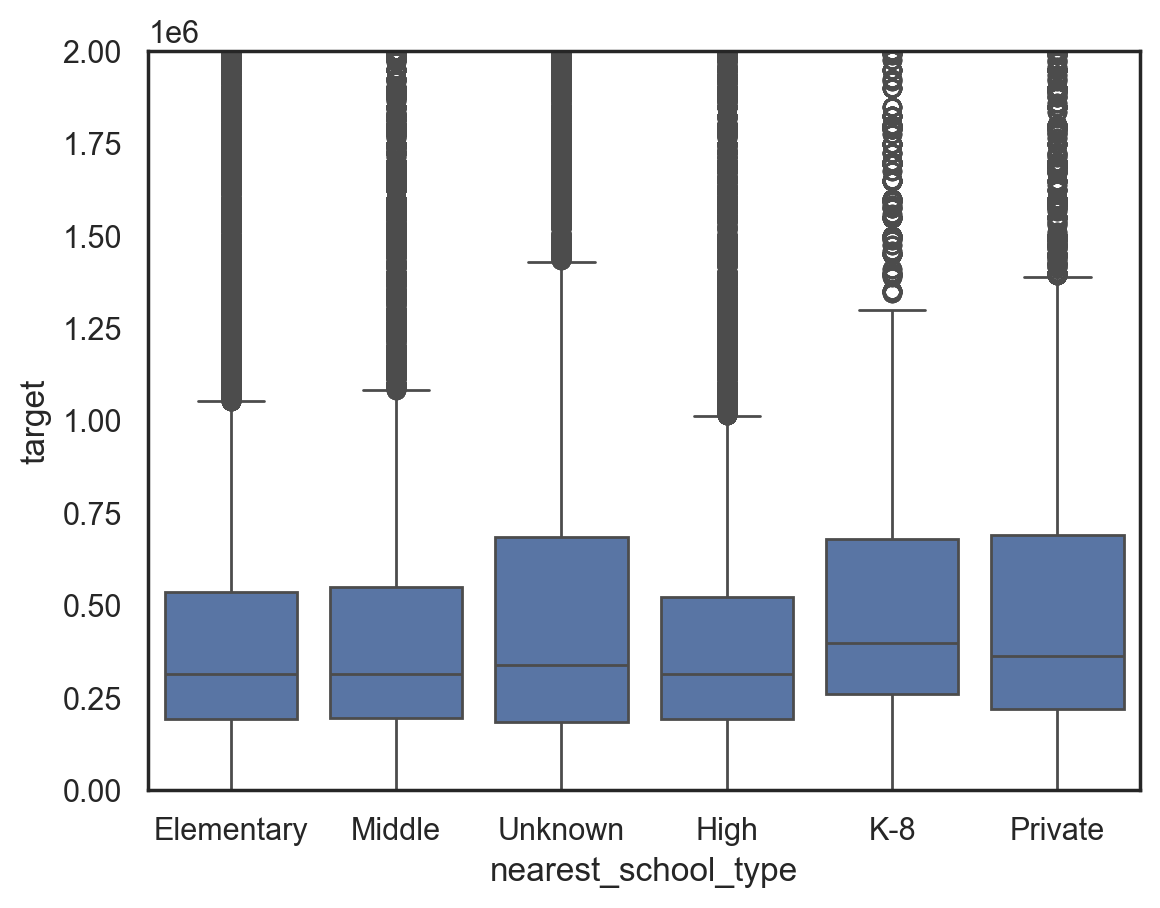

In [91]:
fig = sns.boxplot(x='nearest_school_type', y='target', data=data)
fig.axis(ymin=0, ymax=2000000)

In [92]:
sum(data['nearest_school_rating'].isna())

101299

In [94]:
rating_modes = {} 

for schooltype in ['Unknown', 'Elementary', 'Middle', 'K-8', 'High', 'Private']:
    temp = data[data['nearest_school_type']==schooltype]
    mode = temp['nearest_school_rating'].mode()[0]
    rating_modes[schooltype] = mode

rating_modes

{'Unknown': 3.0,
 'Elementary': 4.0,
 'Middle': 5.0,
 'K-8': 8.0,
 'High': 2.0,
 'Private': 2.0}

(-0.5, 9.5, 0.0, 2000000.0)

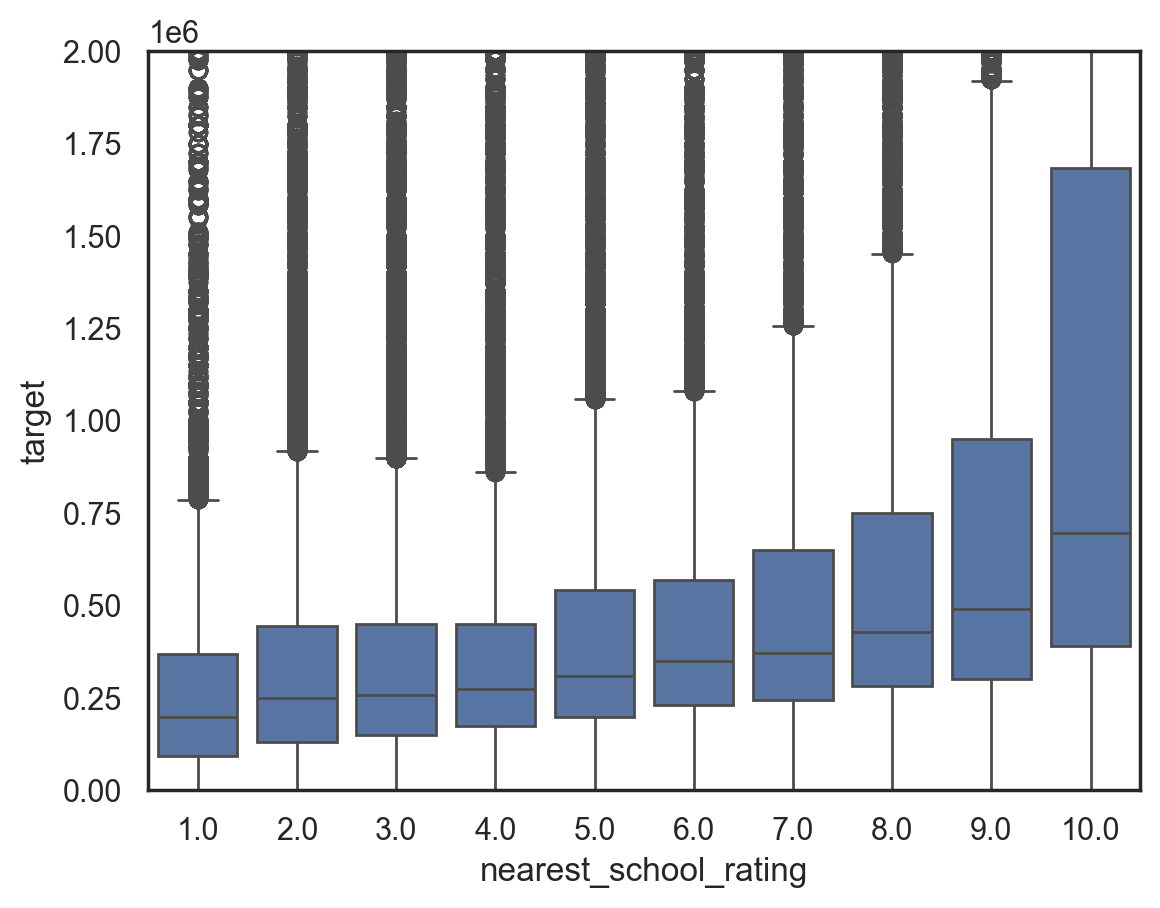

In [95]:
rating_filler = data['nearest_school_type'].apply(lambda x: rating_modes[x])
data['nearest_school_rating'] = data['nearest_school_rating'].fillna(value=rating_filler)

fig = sns.boxplot(x='nearest_school_rating', y='target', data=data)
fig.axis(ymin=0, ymax=2000000)

In [96]:
data['nearest_school_distance'].describe()

count    1.295754e+06
mean     1.007298e+00
std      2.771296e+00
min      0.000000e+00
25%      3.000000e-01
50%      6.000000e-01
75%      1.100000e+00
max      1.187100e+03
Name: nearest_school_distance, dtype: float64

In [97]:
def clamp_distance(number):
    if number < 0.25:
        return 0.25
    elif number > 10:
        return 10
    else:
        return number

data['nearest_school_distance'] = data['nearest_school_distance'].apply(clamp_distance)
data['nearest_school_distance'].describe()

count    1.295754e+06
mean     9.836501e-01
std      1.221337e+00
min      2.500000e-01
25%      3.000000e-01
50%      6.000000e-01
75%      1.100000e+00
max      1.000000e+01
Name: nearest_school_distance, dtype: float64

In [98]:
data['target'].describe()

count    1.329893e+06
mean     6.488561e+05
std      1.867115e+06
min      1.000000e+00
25%      1.940000e+05
50%      3.200000e+05
75%      5.680000e+05
max      1.950000e+08
Name: target, dtype: float64

In [107]:
print(data['target'].quantile(q=0.05))
print(data['target'].quantile(q=0.95))

45000.0
1180000.0


In [108]:
data['target'] = data['target'].apply(lambda x: np.nan if x > 1925000 or x < 45000 else x)

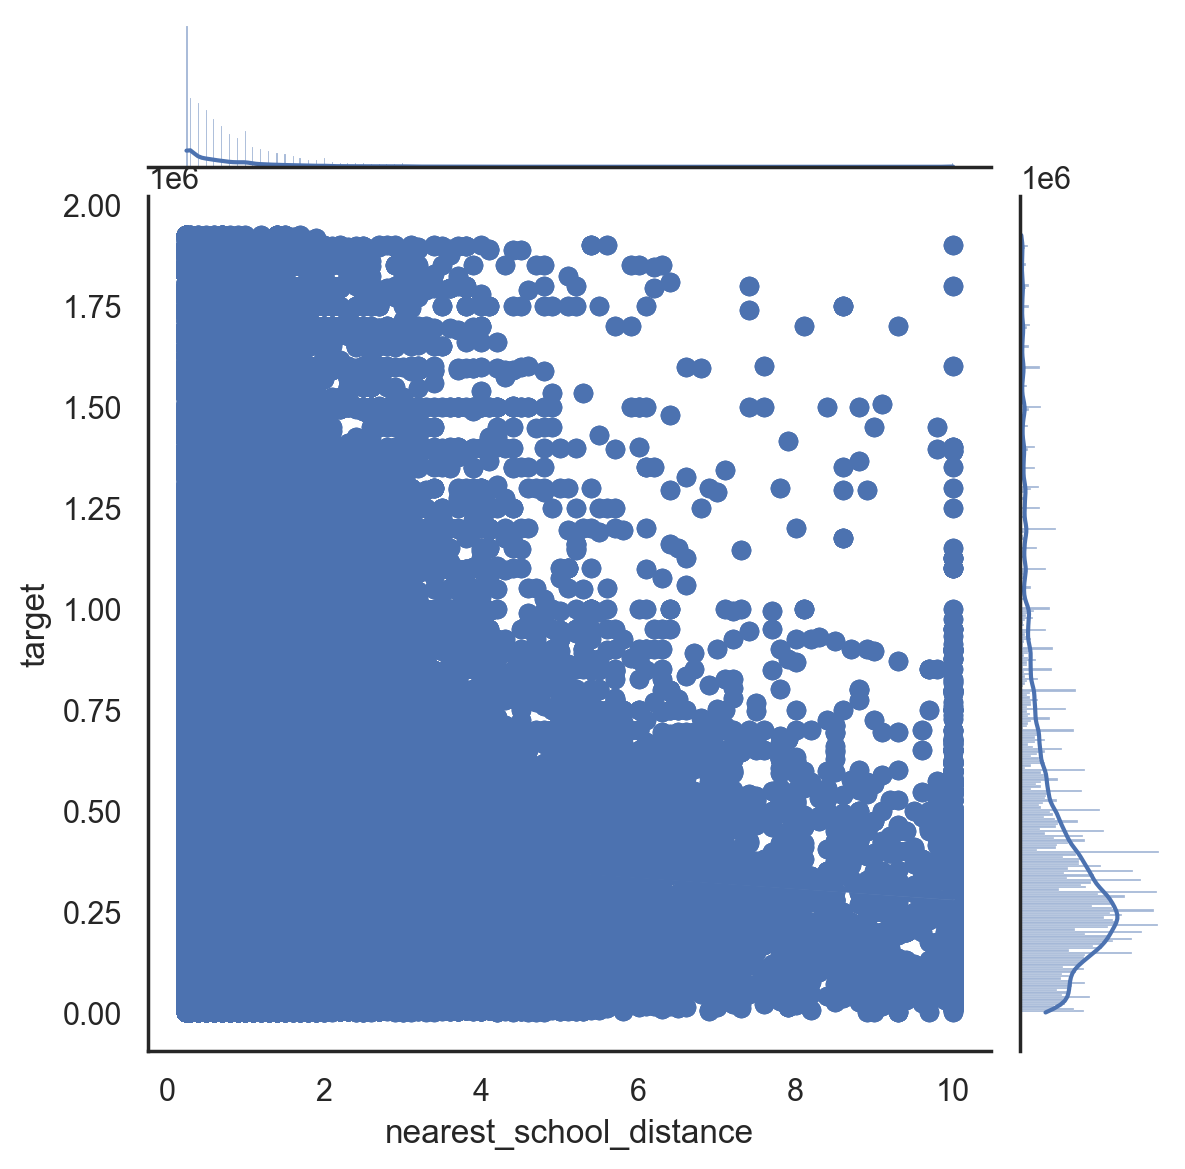

In [101]:
sns.jointplot(x=data['nearest_school_distance'], y=data['target'], kind='reg')

In [109]:
print(data['sqft'].quantile(q=0.05))
print(data['sqft'].quantile(q=0.95))

print(data['lotsize'].quantile(q=0.05))
print(data['lotsize'].quantile(q=0.95))

744.0
3698.0
0.28
9583.0


In [110]:
data['sqft'] = data['sqft'].apply(lambda x: np.nan if x > 4684 or x < 744 else x)
data['lotsize'] = data['lotsize'].apply(lambda x: np.nan if x > 10362 or x < 1500 else x)

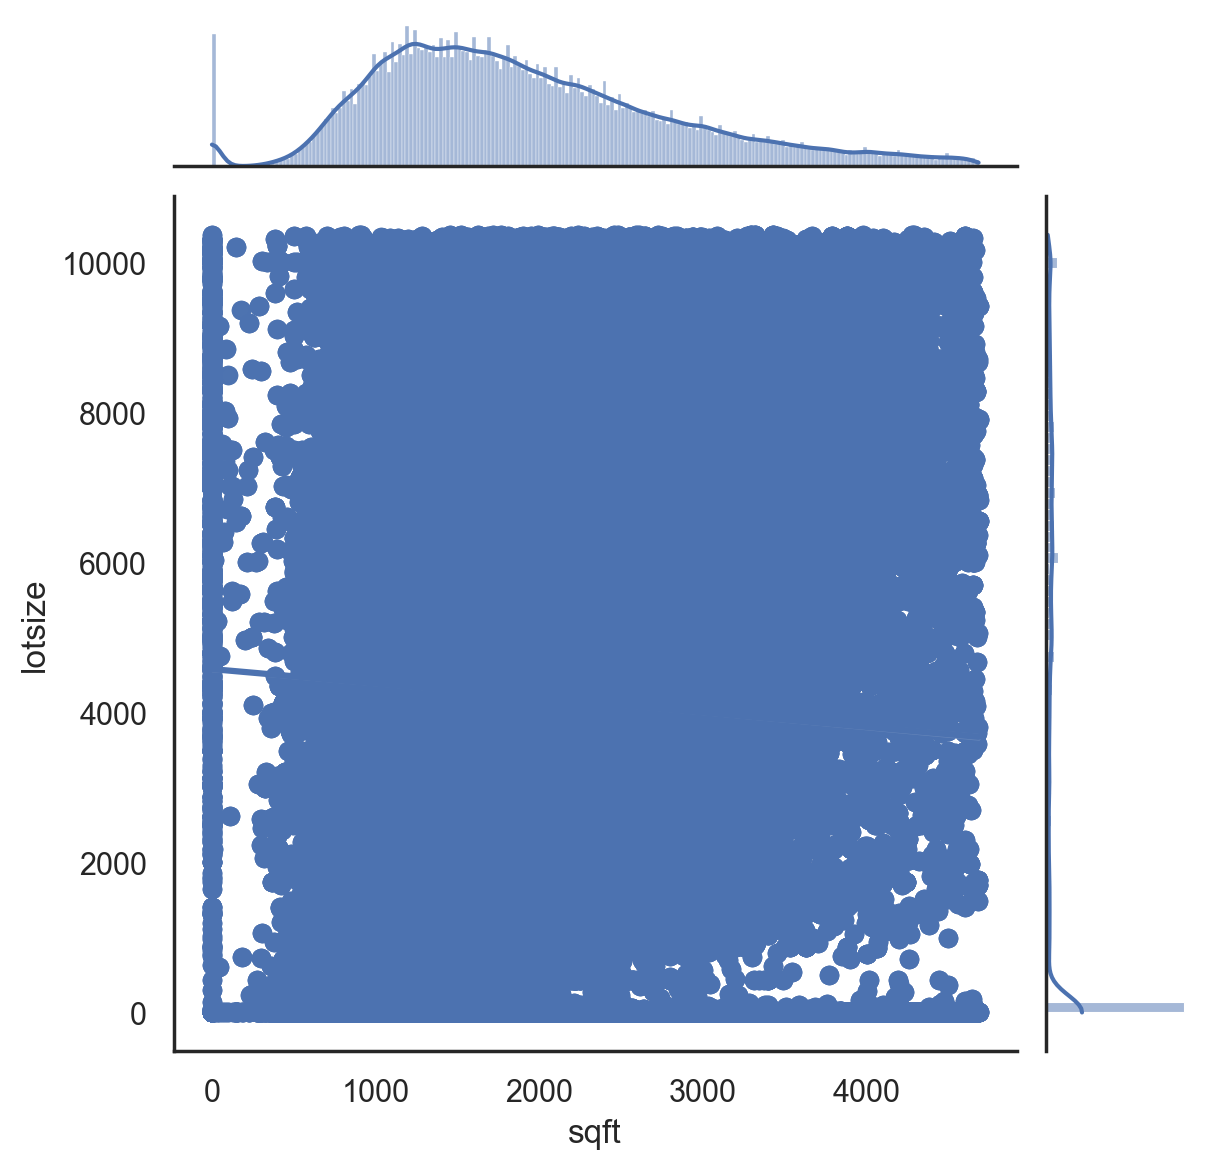

In [104]:
sns.jointplot(x=data['sqft'], y=data['lotsize'], kind='reg')

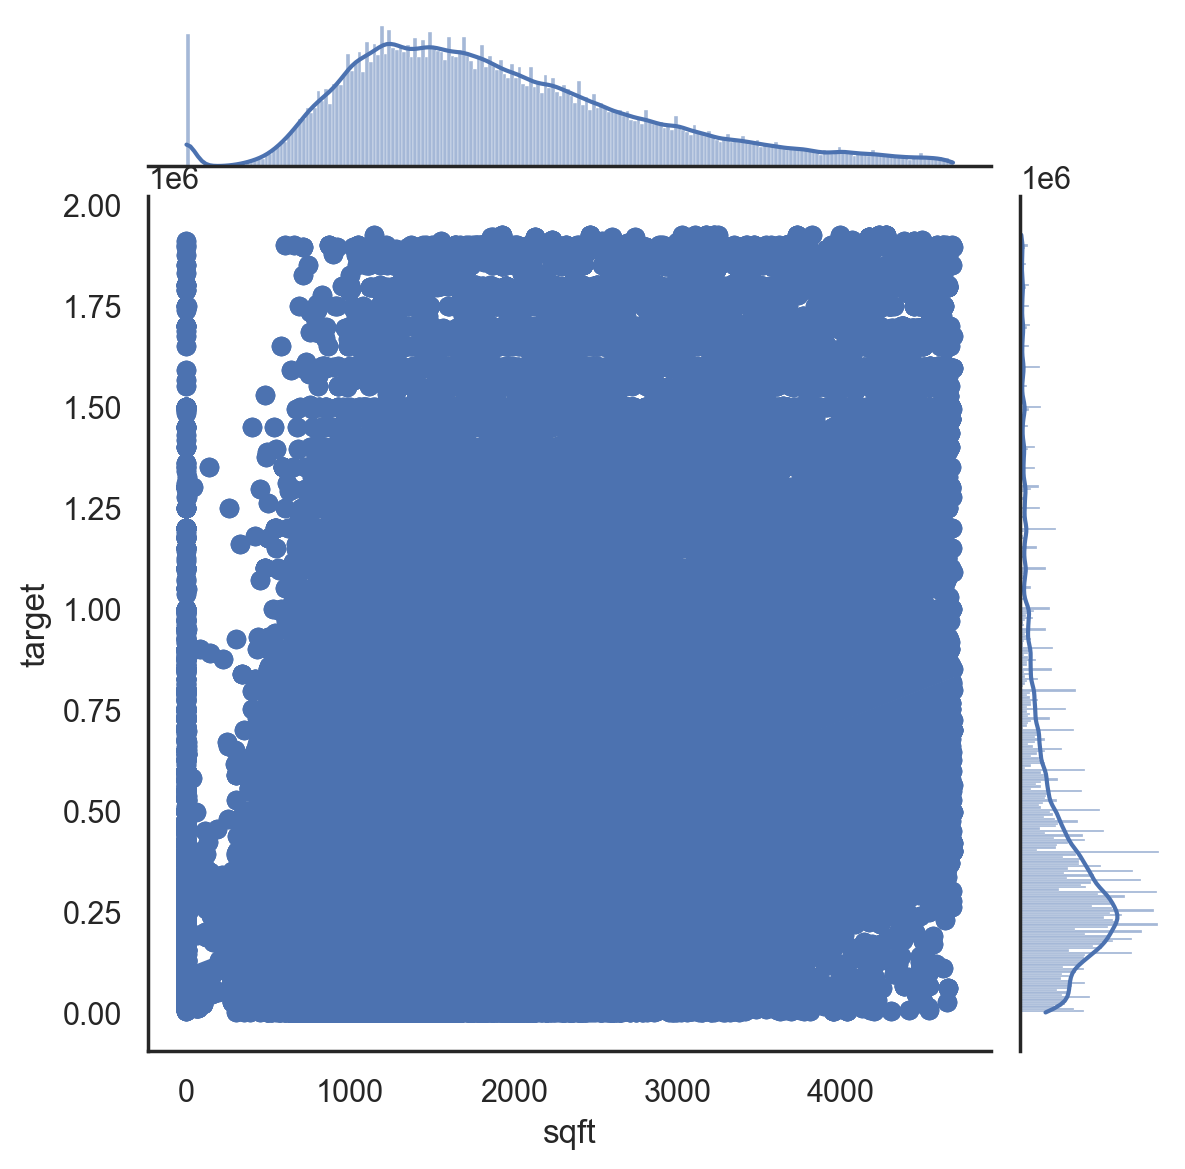

In [105]:
sns.jointplot(x=data['sqft'], y=data['target'], kind='reg')

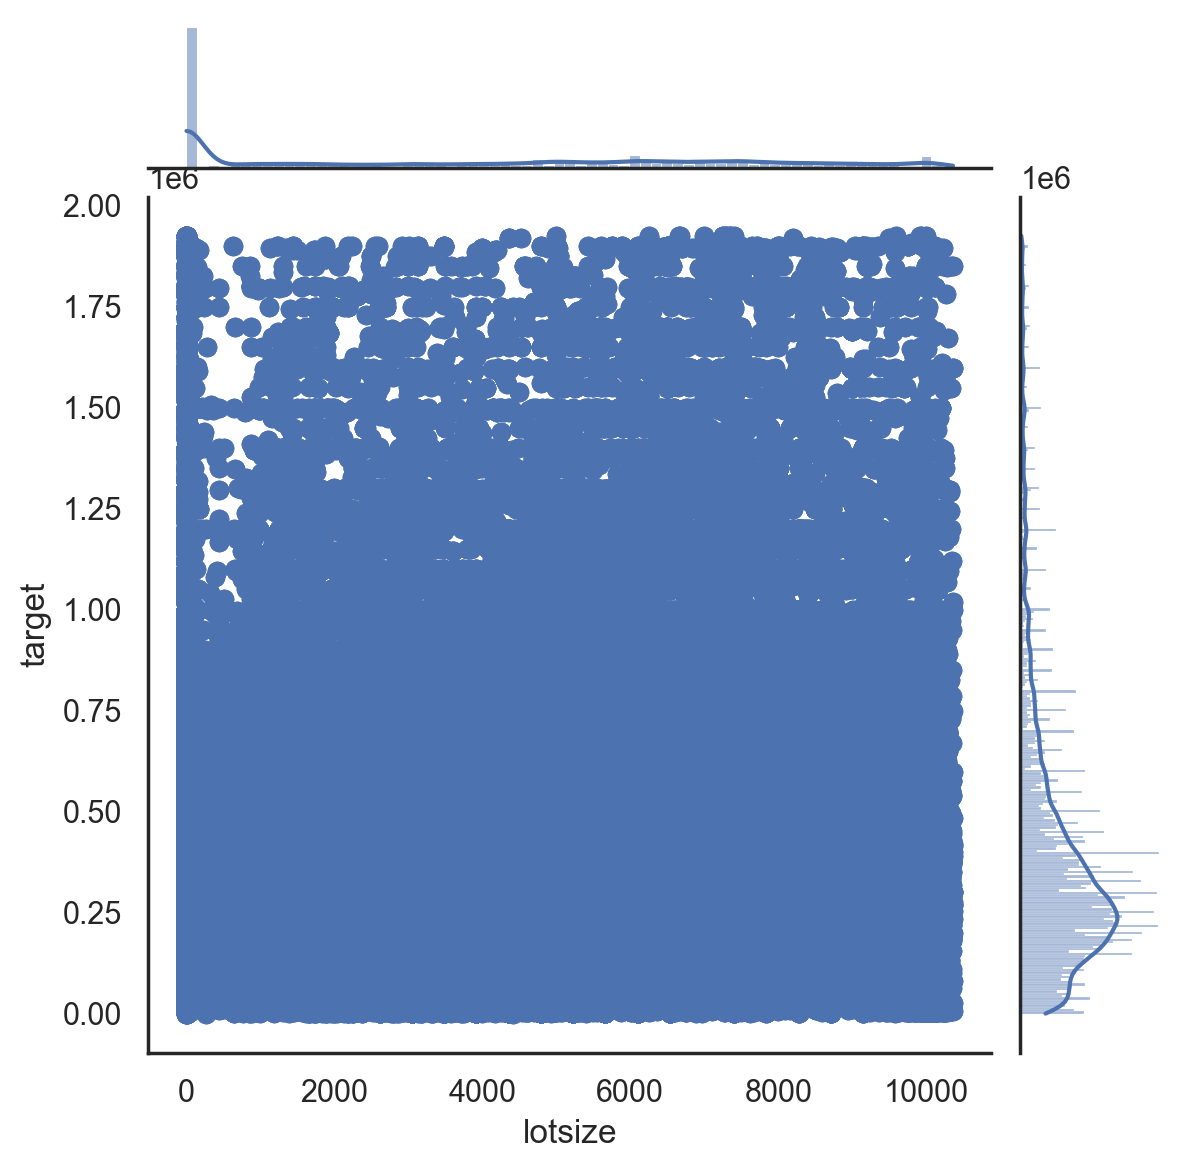

In [106]:
sns.jointplot(x=data['lotsize'], y=data['target'], kind='reg')

In [111]:
for column in ['sqft', 'lotsize', 'nearest_school_distance']:
    med = data[column].median()
    data[column] = data[column].fillna(value=med)

data = data.dropna(subset=['target'], axis=0)

In [112]:
suspicious_zeroes = data[(data['baths']==0)|(data['beds']==0)|(data['stories']==0)]
suspicious_zeroes['propertyType'].value_counts()

propertyType
Single Family                    31789
Condo                             9267
Townhouse                         3395
Multi Family                      2547
Mobile / Manufactured             1374
Land                              1191
Condo/Townhome/Row Home/Co-Op      380
Multi-Family Home                  242
Cooperative                        129
Apartment                          128
Single Family Home                 100
Farms/Ranches                       40
Multiple Occupancy                  15
Miscellaneous                       15
SingleFamilyResidence               10
Name: count, dtype: int64

In [114]:
data['baths'] = data['baths'].apply(lambda x: 1 if x<1 else x)
data['beds'] = data['beds'].apply(lambda x: 1 if x<1 else x)
data['stories'] = data['stories'].apply(lambda x: 1 if x<1 else x)

In [115]:
print(data['baths'].quantile(q=0.95))
print(data['beds'].quantile(q=0.95))
print(data['stories'].quantile(q=0.95))

1250.0
5.0
3.0


In [118]:
data['baths'] = data['baths'].apply(lambda x: np.nan if x>15 else x)
data['beds'] = data['beds'].apply(lambda x: np.nan if x>15 else x)
data['stories'] = data['stories'].apply(lambda x: np.nan if x>5 else x)

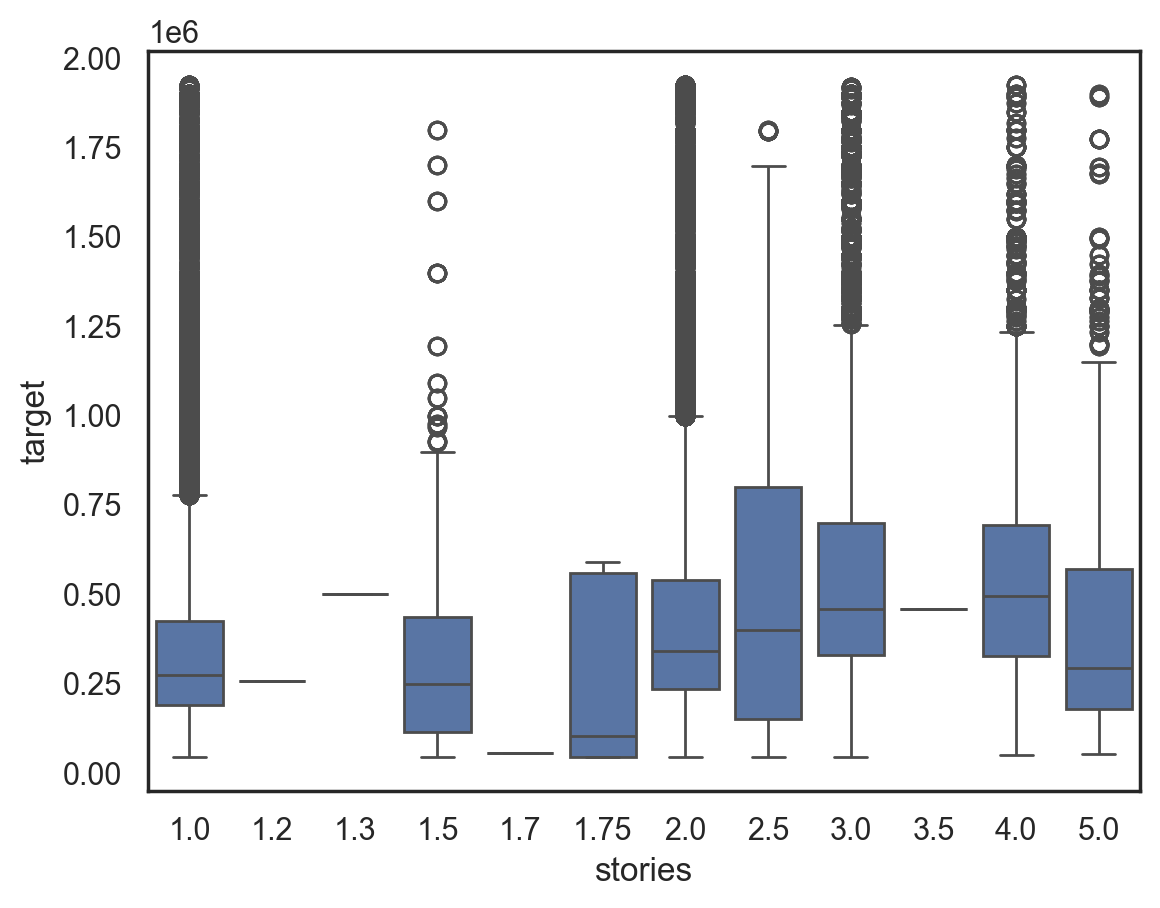

In [120]:
fig = sns.boxplot(x='stories', y='target', data=data)

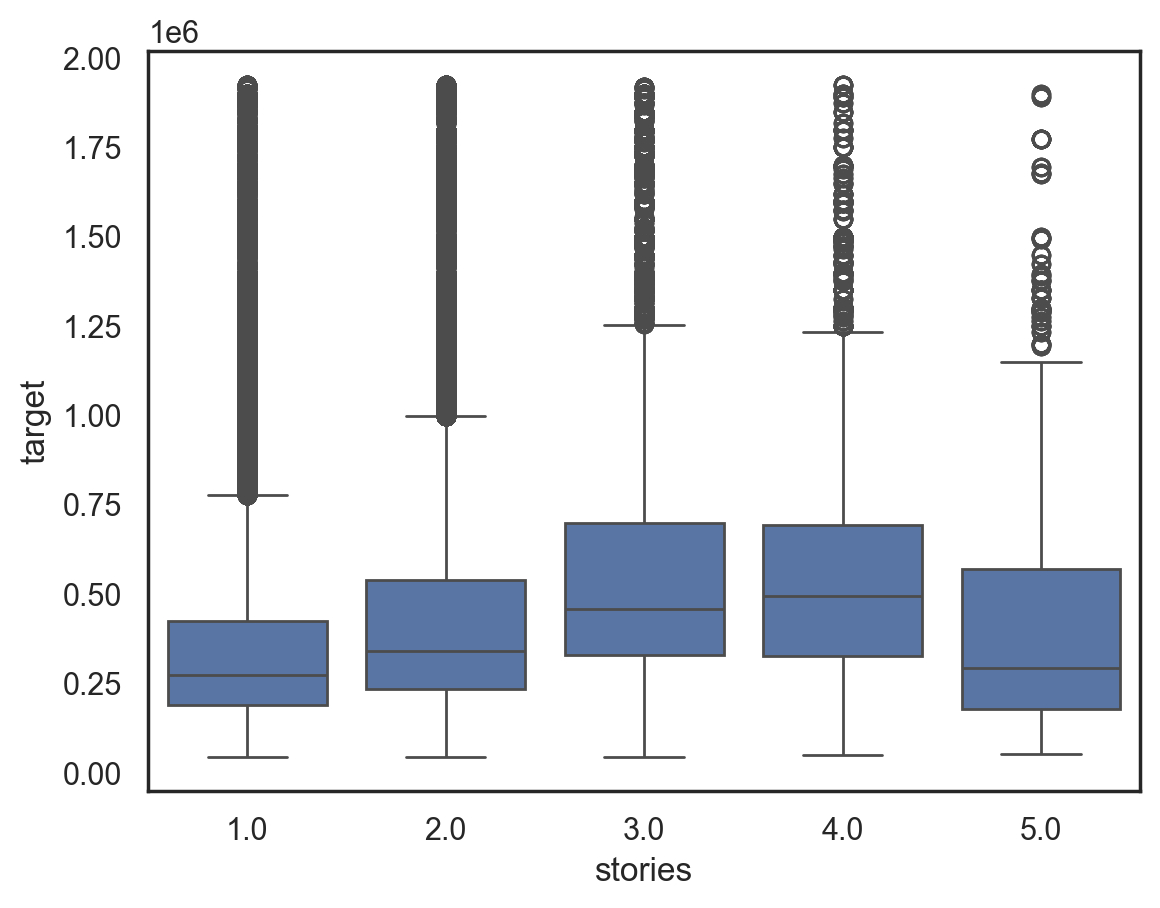

In [126]:
def rounder(number):
    try:
        return round(number)
    except:
        return number
    
data['stories'] = data['stories'].apply(rounder) 
fig = sns.boxplot(x='stories', y='target', data=data)

In [127]:
data = data[data['stories']!=5]
data['stories'] = data['stories'].fillna(value=data['stories'].mode()[0])
data['stories'].value_counts()

stories
1.0    842841
2.0    284084
3.0     60876
4.0     10477
Name: count, dtype: int64

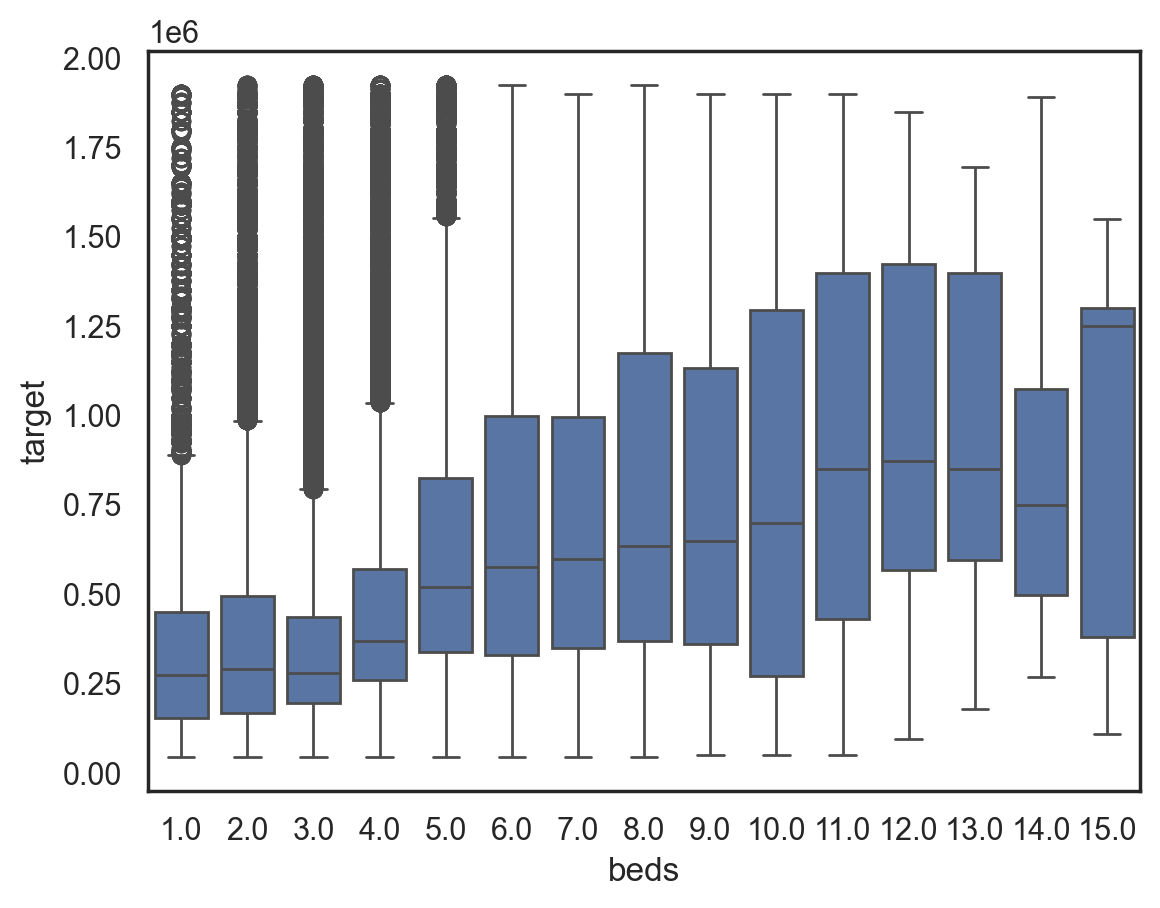

In [130]:
data['beds'] = data['beds'].apply(rounder) 
fig = sns.boxplot(x='beds', y='target', data=data)

In [131]:
data = data[(data['beds']>1)|(data['target']<1000000)]
data['beds'] = data['beds'].fillna(value=data['beds'].mode()[0])
data['beds'].value_counts()

beds
3.0     632754
4.0     244616
2.0     175963
5.0      66792
1.0      31255
6.0      15800
7.0       3707
8.0       2775
9.0       1116
10.0       674
12.0       418
11.0       246
13.0       111
14.0        91
15.0        75
Name: count, dtype: int64

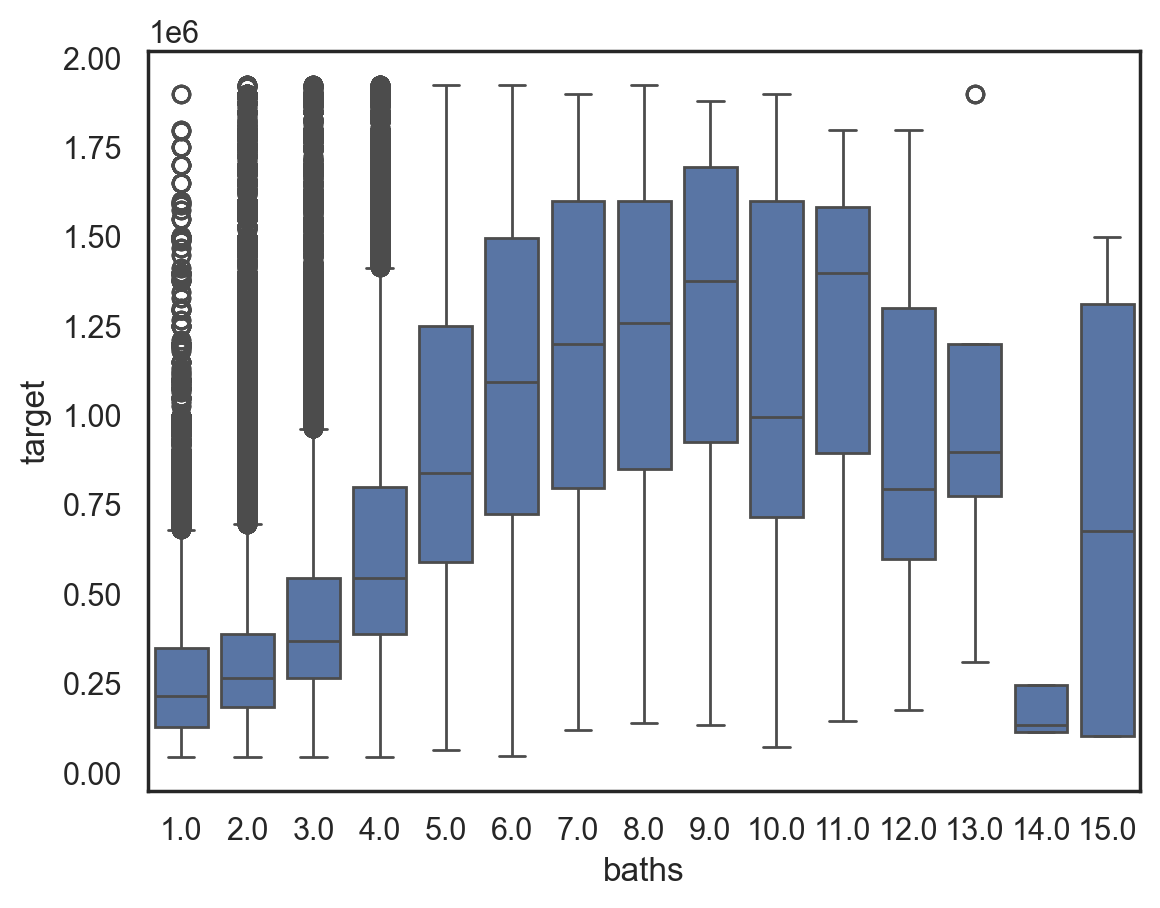

In [134]:
data['baths'] = data['baths'].apply(rounder)
fig = sns.boxplot(x='baths', y='target', data=data)

In [138]:
data = data[data['baths']<13]
data = data[(data['baths']>1)|(data['target']<1200000)]
data['baths'] = data['baths'].fillna(value=data['baths'].mode()[0])
data['baths'].value_counts()

baths
2.0     409580
3.0     246406
4.0     113628
1.0      59275
5.0      27105
6.0       9774
7.0       3051
8.0       1405
9.0        351
10.0       260
12.0       108
11.0        95
Name: count, dtype: int64

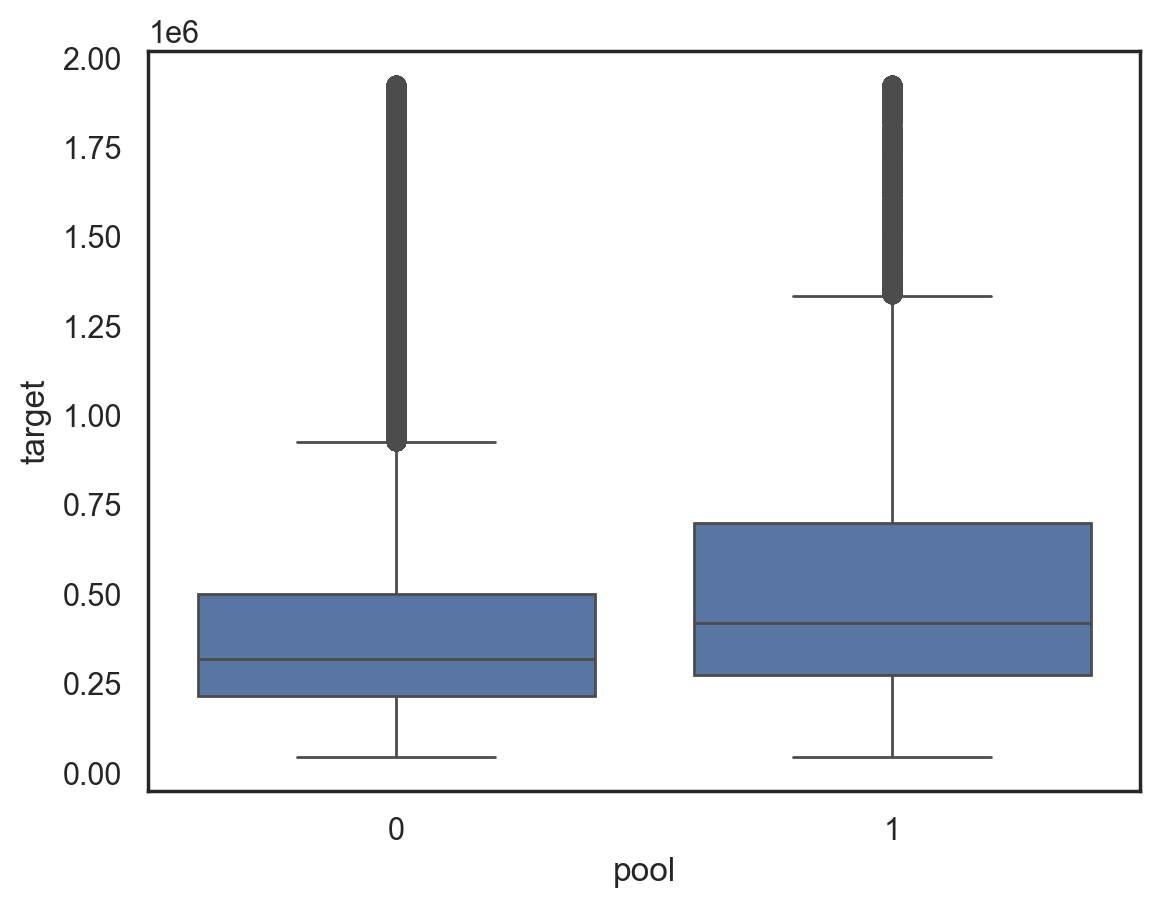

In [139]:
fig = sns.boxplot(x='pool', y='target', data=data)

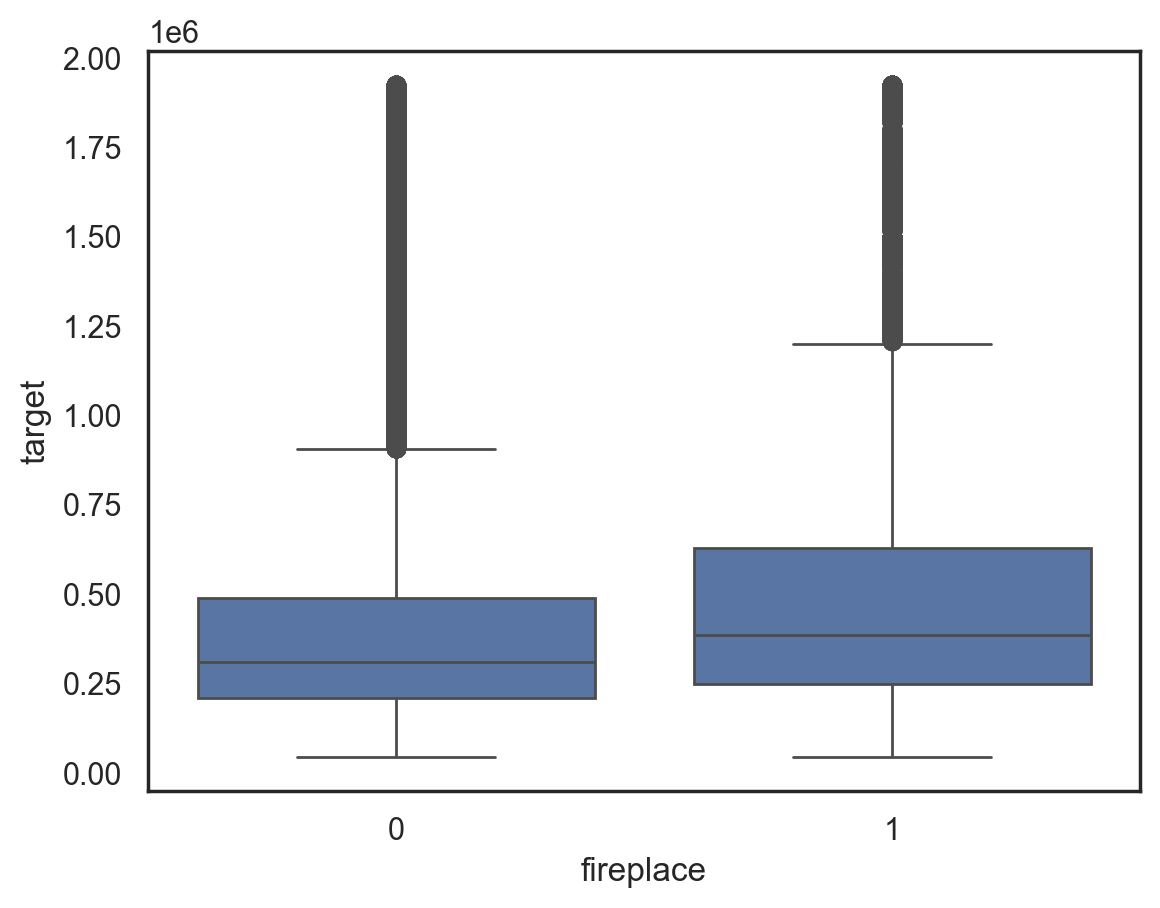

In [140]:
fig = sns.boxplot(x='fireplace', y='target', data=data)

In [142]:
data['state'].value_counts()[:10]

state
TX    239213
FL    234437
CA     71036
NC     54855
TN     39290
WA     36320
NV     34370
IL     25941
GA     18085
CO     17625
Name: count, dtype: int64

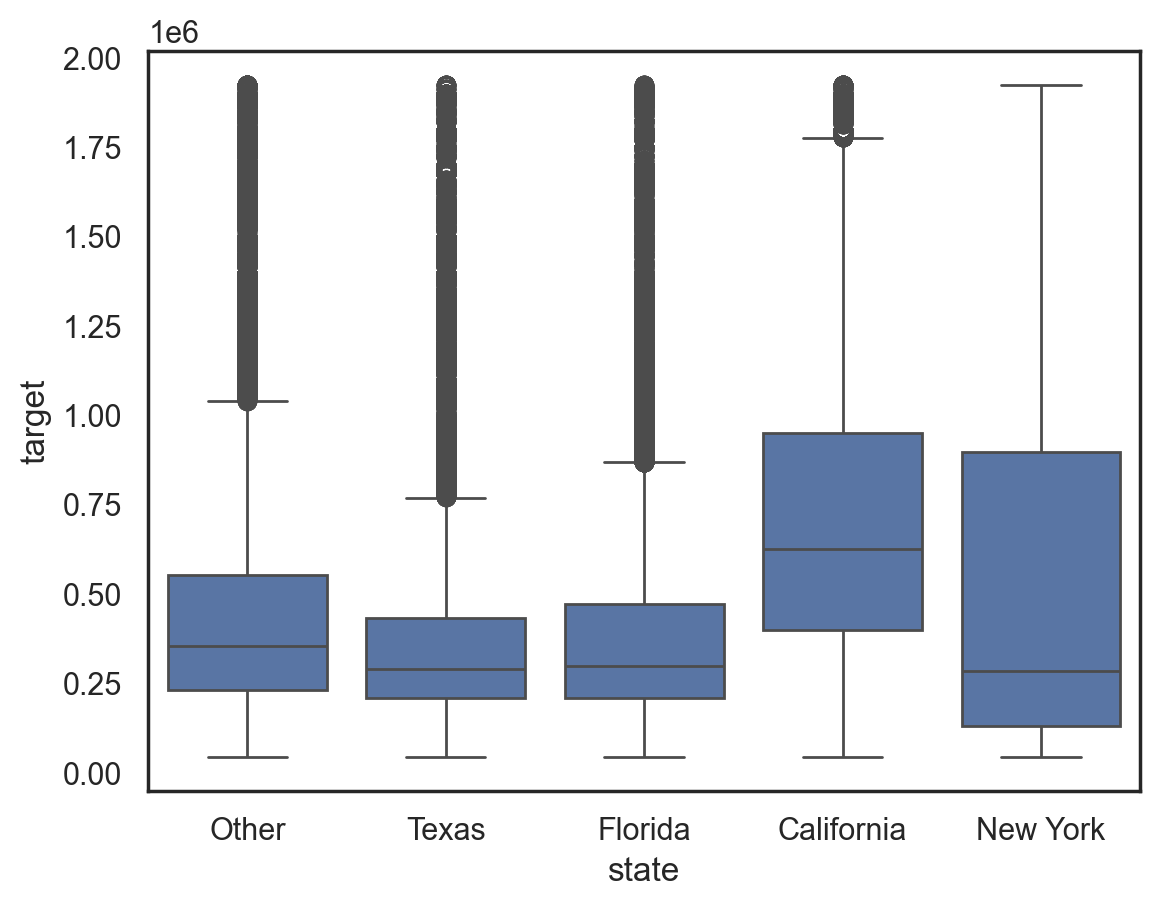

In [143]:
important_states = {'TX': 'Texas', 'FL': 'Florida', 'CA': 'California', 'NY':'New York'}

def clean_state_names(string):
    if string in important_states.keys():
        return important_states[string]
    else:
        return 'Other'
    
data['state'] = data['state'].apply(clean_state_names)

fig = sns.boxplot(x='state', y='target', data=data)

In [144]:
data['status'].value_counts()[:10]

status
for sale                     411402
For sale                     169478
Active                        71822
New construction              22460
foreclosure                   11796
Pending                        9719
Pre-foreclosure                6642
Under Contract Show            4005
P                              3970
Pre-foreclosure / auction      3777
Name: count, dtype: int64

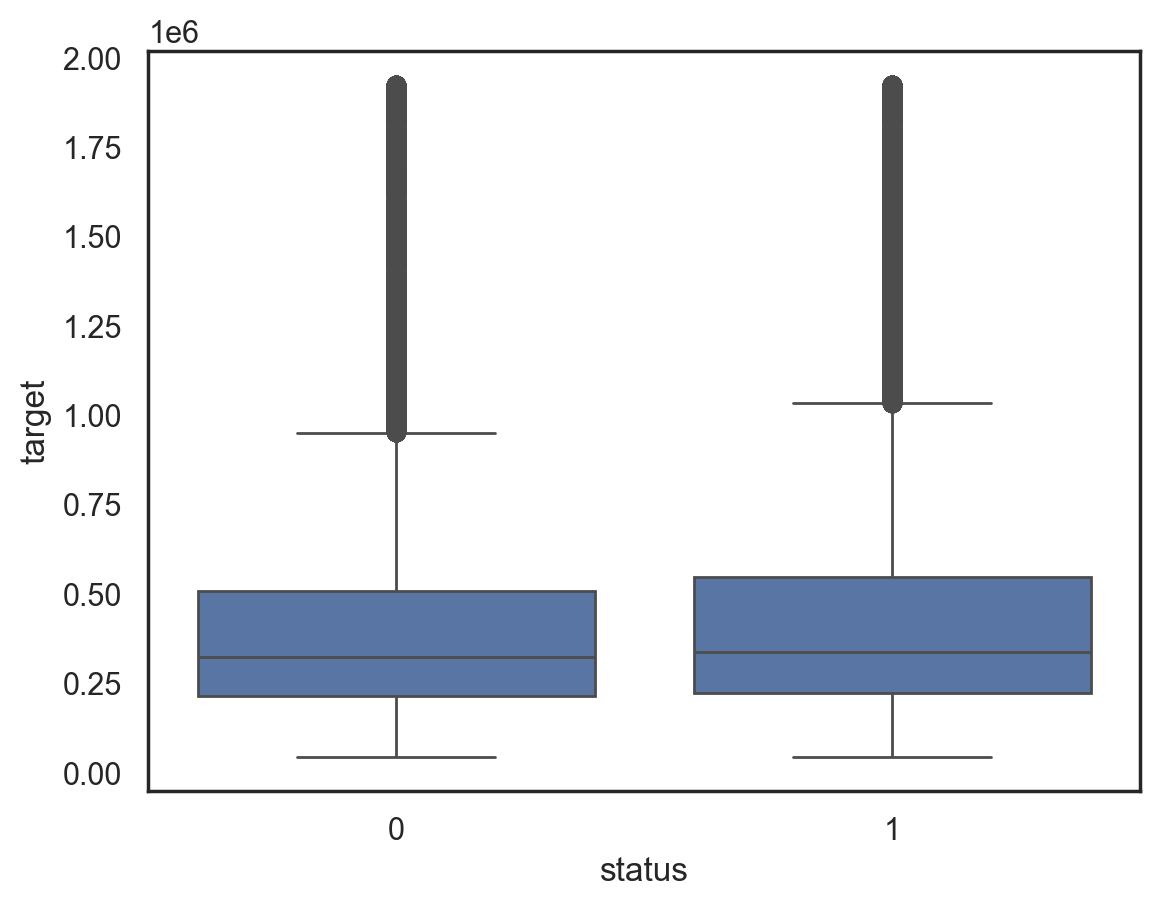

In [149]:
data['status'] = data['status'].fillna(value='unknown')
data['status'] = data['status'].apply(lambda x: 1 if x=='for sale' or x=='For sale' else 0)

fig = sns.boxplot(x='status', y='target', data=data)

In [150]:
data['propertyType'].value_counts()[:10]

propertyType
single-family home               294695
Single Family                    244805
Single Family Home                69425
condo                             64654
Condo                             59790
townhouse                         41432
Townhouse                         27860
Condo/Townhome/Row Home/Co-Op     25181
multi-family                      15203
Multi Family                       6868
Name: count, dtype: int64

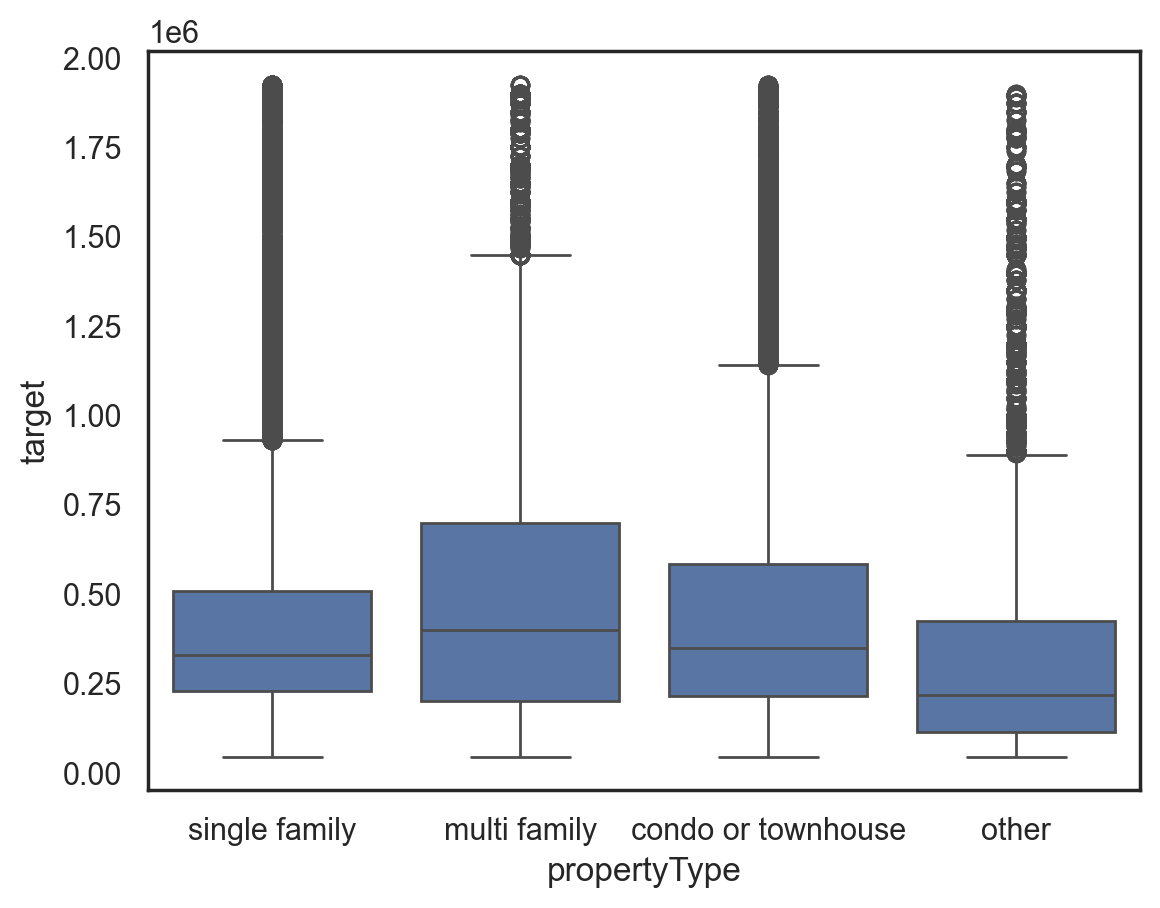

In [151]:
def clean_property_types(string):
    string = string.lower()
    if 'single' in string:
        return 'single family'
    elif 'condo' in string or 'townhouse' in string:
        return 'condo or townhouse'
    elif 'multi' in string:
        return 'multi family'
    else:
        return 'other'
    
data['propertyType'] = data['propertyType'].fillna(value='other')   
data['propertyType'] = data['propertyType'].apply(clean_property_types)
fig = sns.boxplot(x='propertyType', y='target', data=data)

In [152]:
data['Heating'].value_counts()[:10]

Heating
Forced Air    259080
Forced air    198102
Other          97266
No Data        30040
Gas            23740
Electric       19896
Heat Pump      18956
Heat pump      10815
Wall            9853
Baseboard       8824
Name: count, dtype: int64

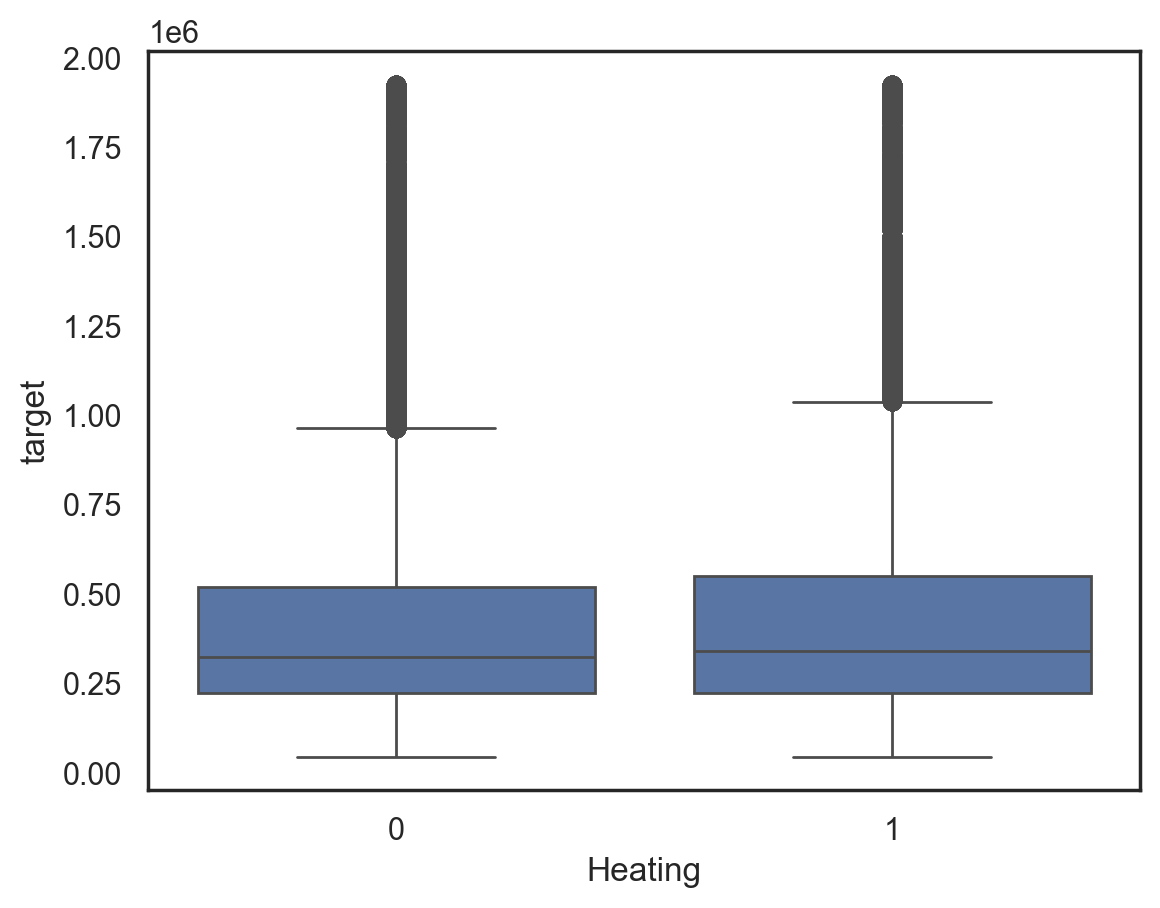

In [153]:
data['Heating'] = data['Heating'].fillna(value='unknown')
data['Heating'] = data['Heating'].apply(lambda x: 1 if x=='Forced Air' or x=='Forced air' else 0)

fig = sns.boxplot(x='Heating', y='target', data=data)

In [154]:
data['Cooling'].value_counts()[:10]

Cooling
Central             553228
No Data              38877
null                 18439
Central Air          13723
Central Electric     12315
Wall                 11084
Cooling System        7411
Other                 5982
Central A/C           5585
Refrigeration         3905
Name: count, dtype: int64

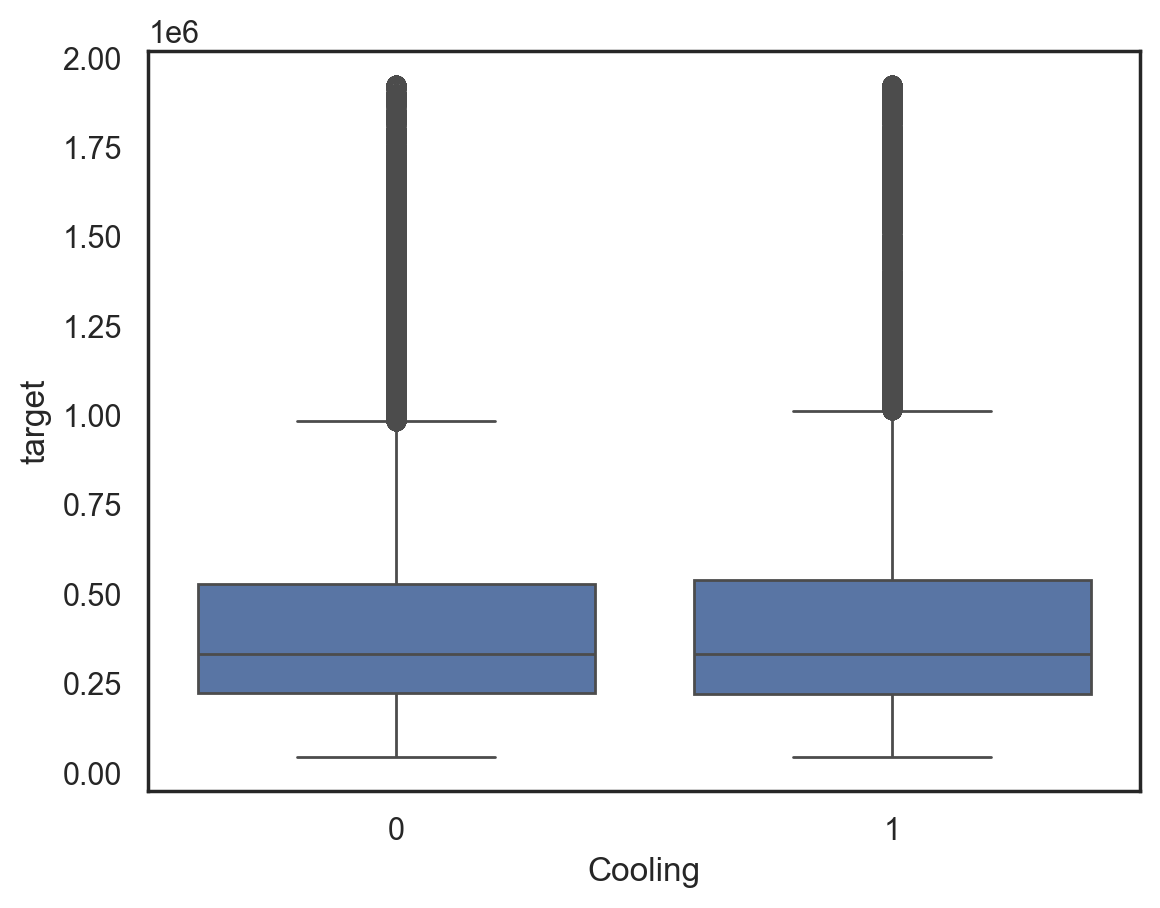

In [155]:
data['Cooling'] = data['Cooling'].fillna(value='unknown')
data['Cooling'] = data['Cooling'].apply(lambda x: 1 if 'Central' in x else 0)

fig = sns.boxplot(x='Cooling', y='target', data=data)

In [156]:
data['Parking'].value_counts()[:10]

Parking
Attached Garage    242009
2 spaces           117265
1 space             56711
No Data             46752
Detached Garage     36872
Carport             22699
3 spaces            18384
4 spaces            10620
Off Street           9883
2                    9055
Name: count, dtype: int64

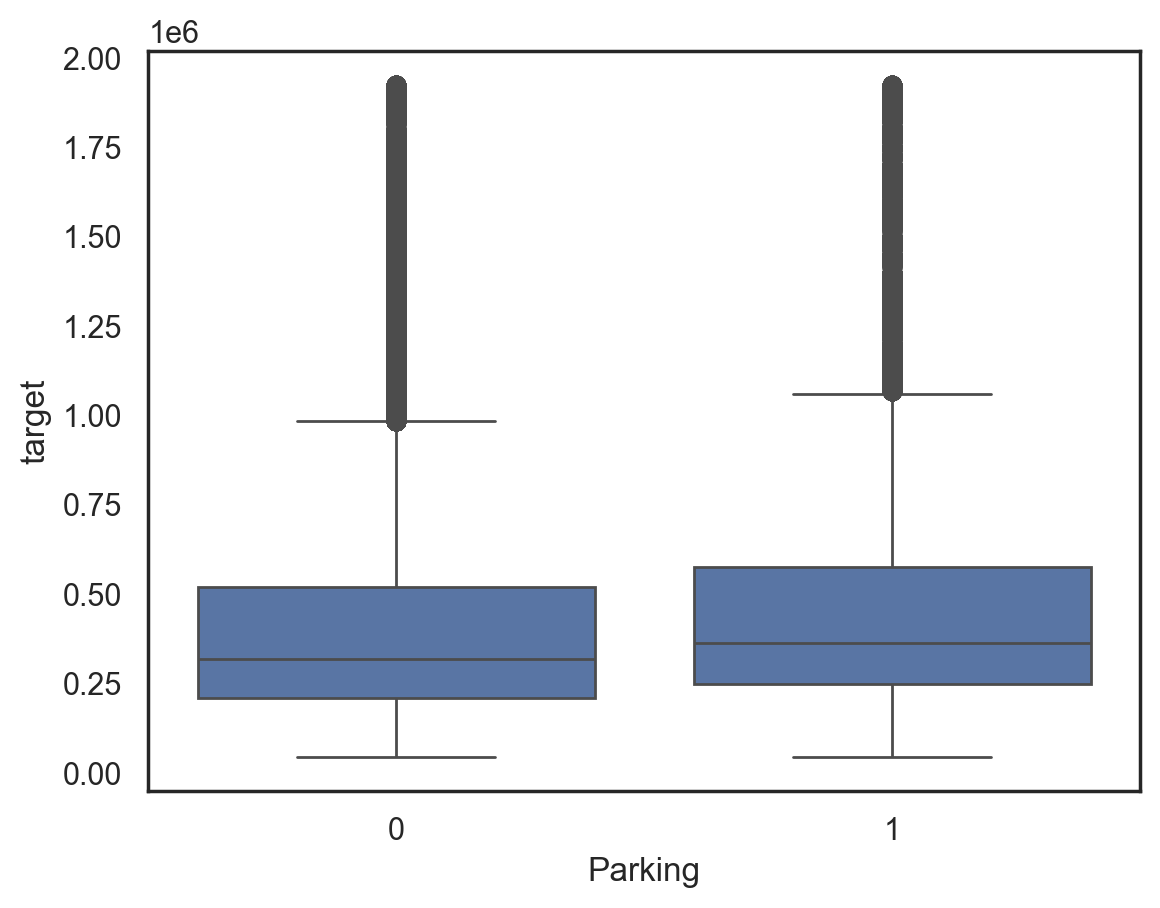

In [158]:
data['Parking'] = data['Parking'].fillna(value='unknown')
data['Parking'] = data['Parking'].apply(lambda x: 1 if x=='Attached Garage' else 0)

fig = sns.boxplot(x='Parking', y='target', data=data)

In [160]:
data['parking slots'].value_counts()

parking slots
2.0       126737
1.0        64557
3.0        19808
4.0        12331
6.0         3070
           ...  
2020.0         5
112.0          4
105.0          4
230.0          4
93.0           4
Name: count, Length: 64, dtype: int64

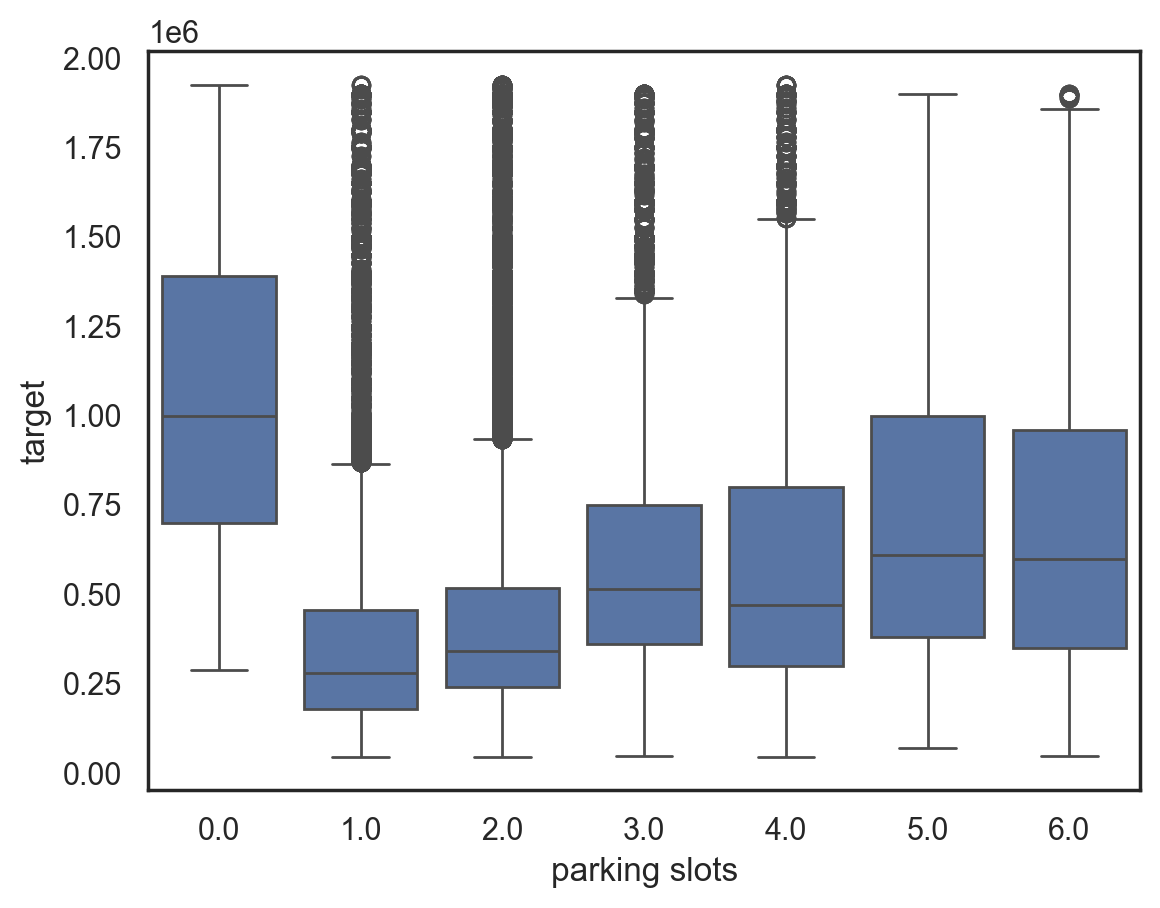

In [161]:
data['parking slots'] = data['parking slots'].apply(lambda x: np.nan if x>6 else x)
fig = sns.boxplot(x='parking slots', y='target', data=data)

In [162]:
data['parking slots'] = data['parking slots'].fillna(value=data['parking slots'].mode()[0])

In [170]:
data = pd.get_dummies(data, columns=['nearest_school_type', 'propertyType', 'street', 'state'])

<Axes: >

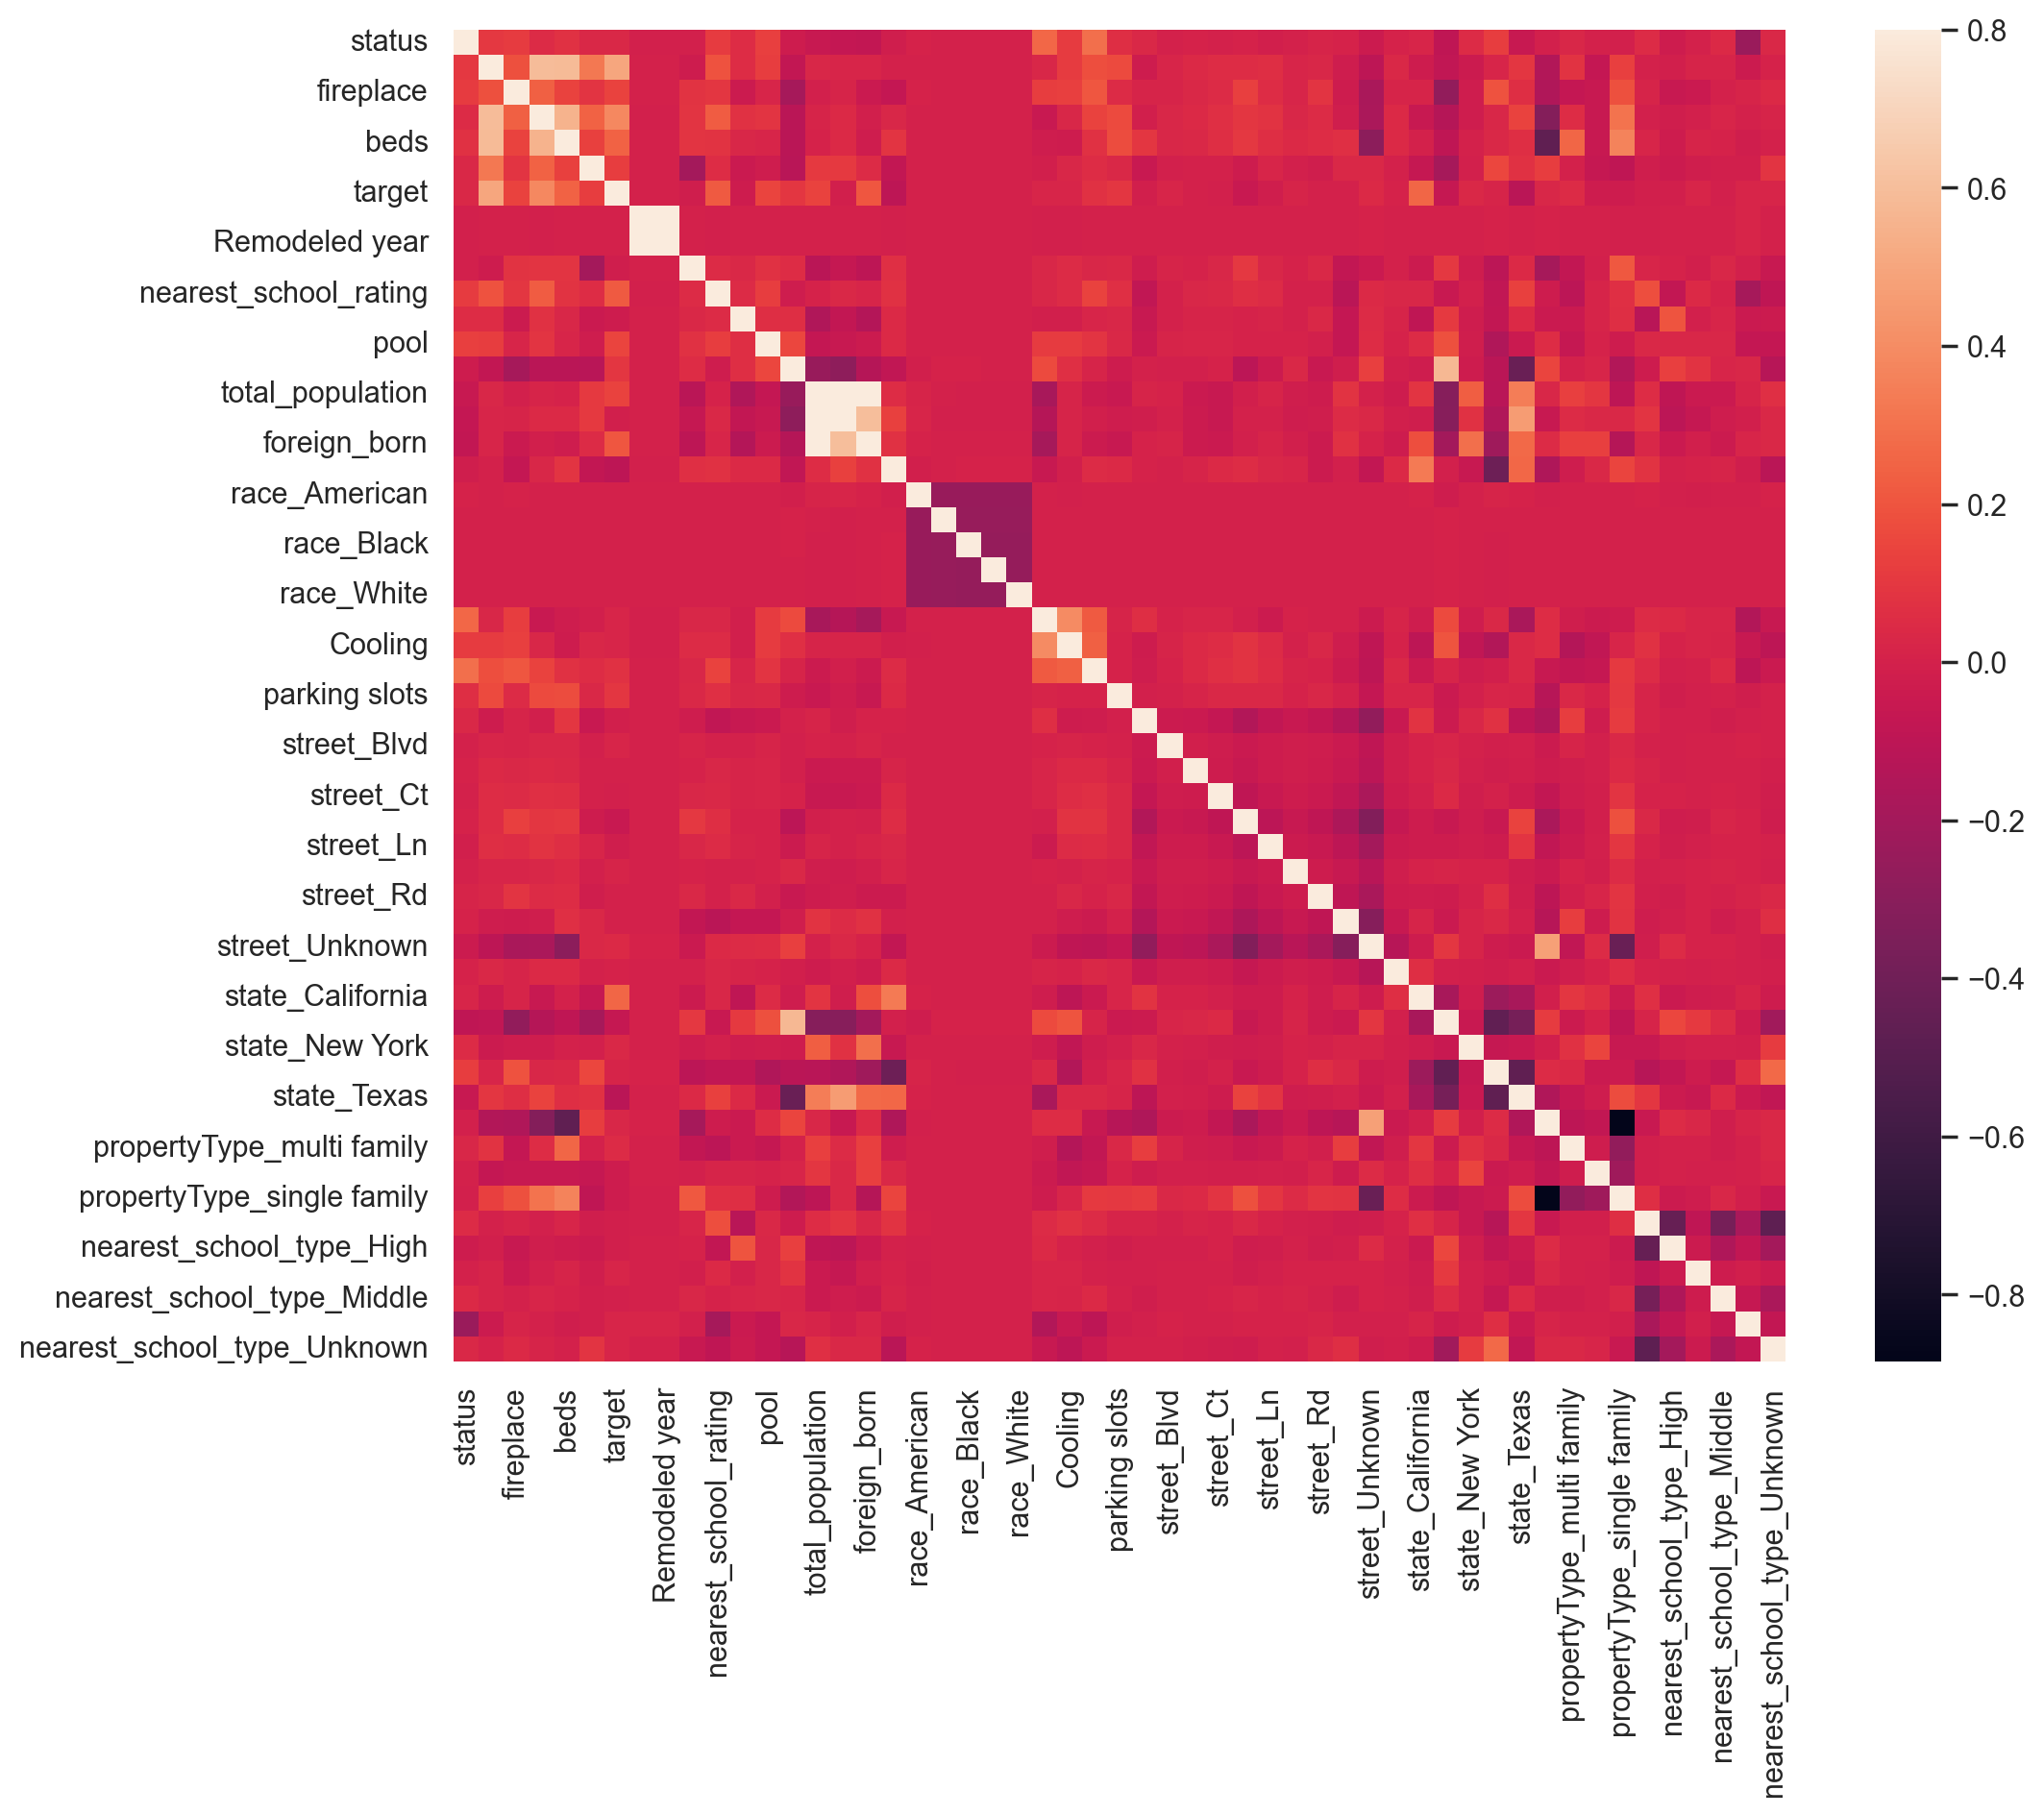

In [171]:
corrmat = data.corr()
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, vmax=.8, square=True)

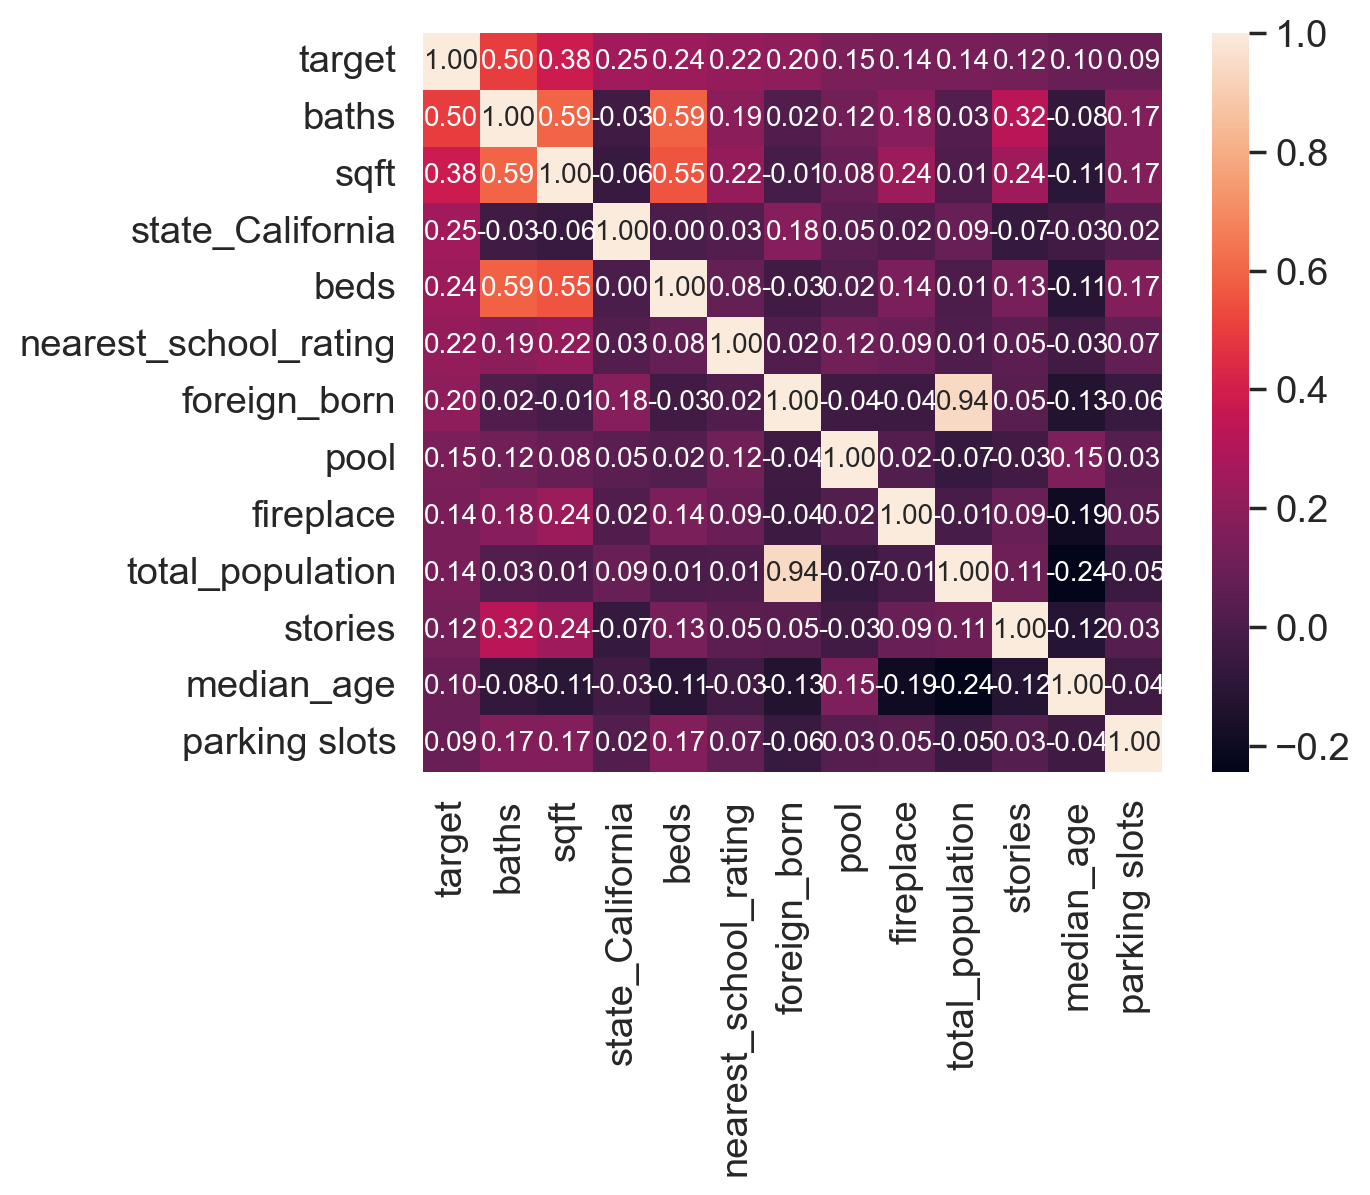

In [177]:
k = 13 
cols = corrmat.nlargest(k, 'target')['target'].index
cm = data[cols].corr()
sns.set(font_scale=1.25)
hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values)
plt.show()

In [178]:
most_corr = pd.DataFrame(cols)
most_corr.columns = ['Most Correlated Features']
most_corr

,Most Correlated Features
0,target
1,baths
2,sqft
3,state_California
4,beds
5,nearest_school_rating
6,foreign_born
7,pool
8,fireplace
9,total_population


In [189]:
print(data['Year built'].quantile(q=0.05), data['Year built'].quantile(q=0.95))
print(data['Remodeled year'].quantile(q=0.05), data['Remodeled year'].quantile(q=0.95))

1920.0 2019.0
1925.0 2019.0


In [190]:
data['Year built'] = data['Year built'].apply(lambda x: np.nan if x<1920 or x>2019 else x)
data['Remodeled year'] = data['Remodeled year'].apply(lambda x: np.nan if x<1925 or x>2019 else x)

In [191]:
data['Year built'] = data['Year built'].fillna(value=data['Year built'].mode()[0])
data['Remodeled year'] = data['Remodeled year'].fillna(value=data['Remodeled year'].mode()[0])

Этап 4. Построение базовой модели. Стандартизация данных.

In [182]:
x = data.drop(labels='target', axis=1)
y = data['target']
x_train, x_test, y_train, y_test = train_test_split(x, y)

model_baseline = GradientBoostingRegressor(random_state=42)
model_baseline.fit(x_train, y_train)

y_pred = model_baseline.predict(x_test)

print(mean_squared_error(y_test, y_pred))
print(r2_score(y_test, y_pred))

39494784835.99853
0.6437727662223438



 mu = 436712.04 and sigma = 333505.22



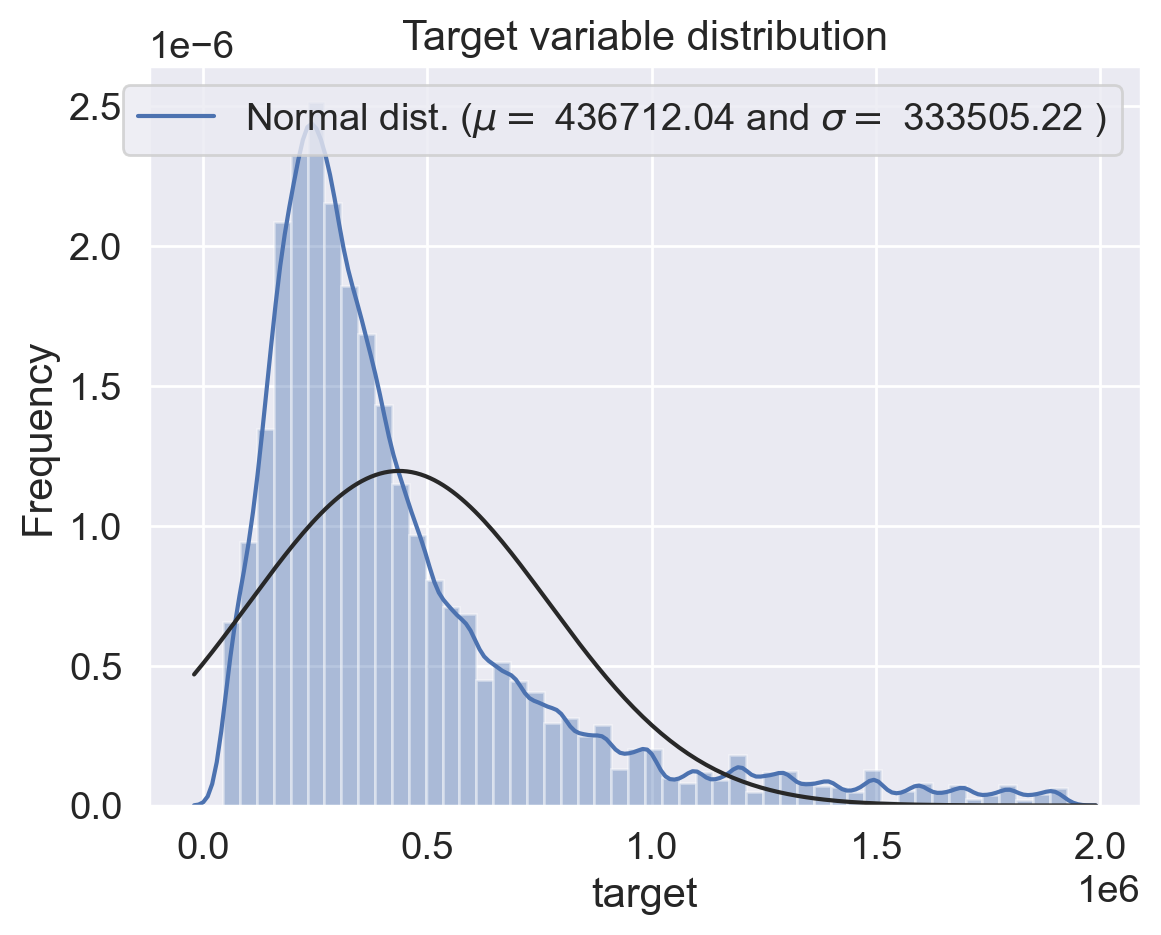

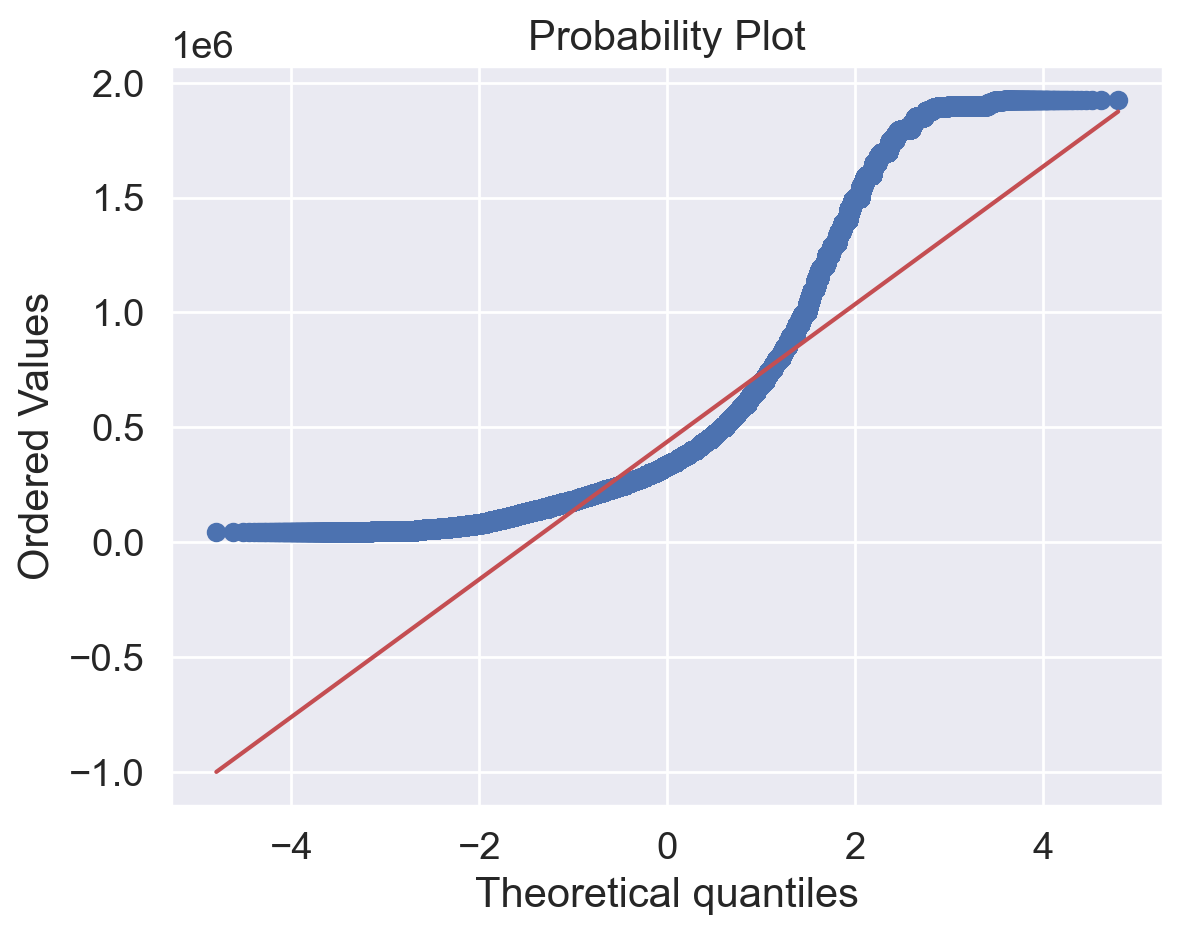

Skewness: 1.913558
Kurtosis: 3.994650


In [186]:
sns.distplot(data['target'], fit=norm);

# Get the fitted parameters used by the function
(mu, sigma) = norm.fit(data['target'])
print( '\n mu = {:.2f} and sigma = {:.2f}\n'.format(mu, sigma))
plt.legend(['Normal dist. ($\mu=$ {:.2f} and $\sigma=$ {:.2f} )'.format(mu, sigma)],
            loc='best')
plt.ylabel('Frequency')
plt.title('Target variable distribution')

fig = plt.figure()
res = stats.probplot(data['target'], plot=plt)
plt.show()

print("Skewness: %f" % data['target'].skew())
print("Kurtosis: %f" % data['target'].kurt())

In [187]:
data['target'] = np.log1p(data['target'])


 mu = 12.75 and sigma = 0.69



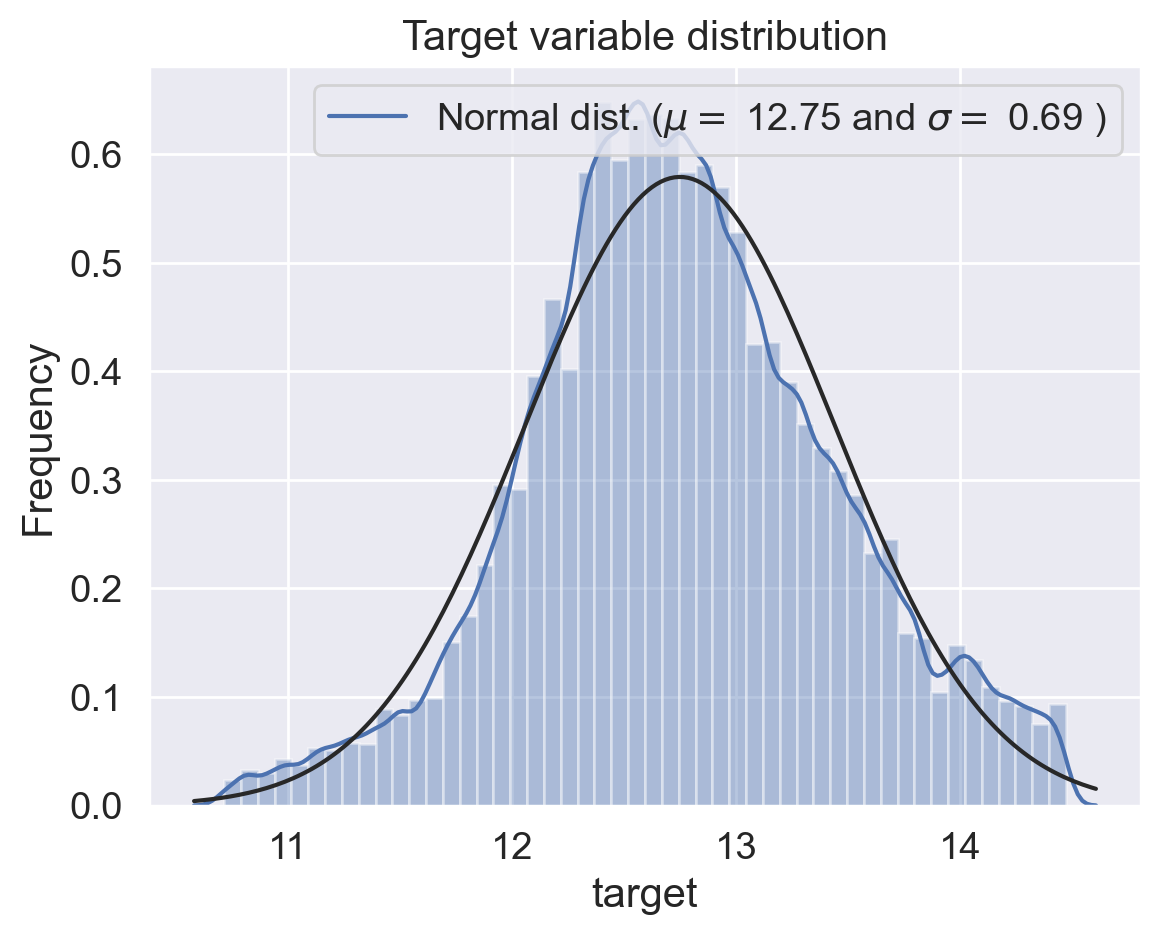

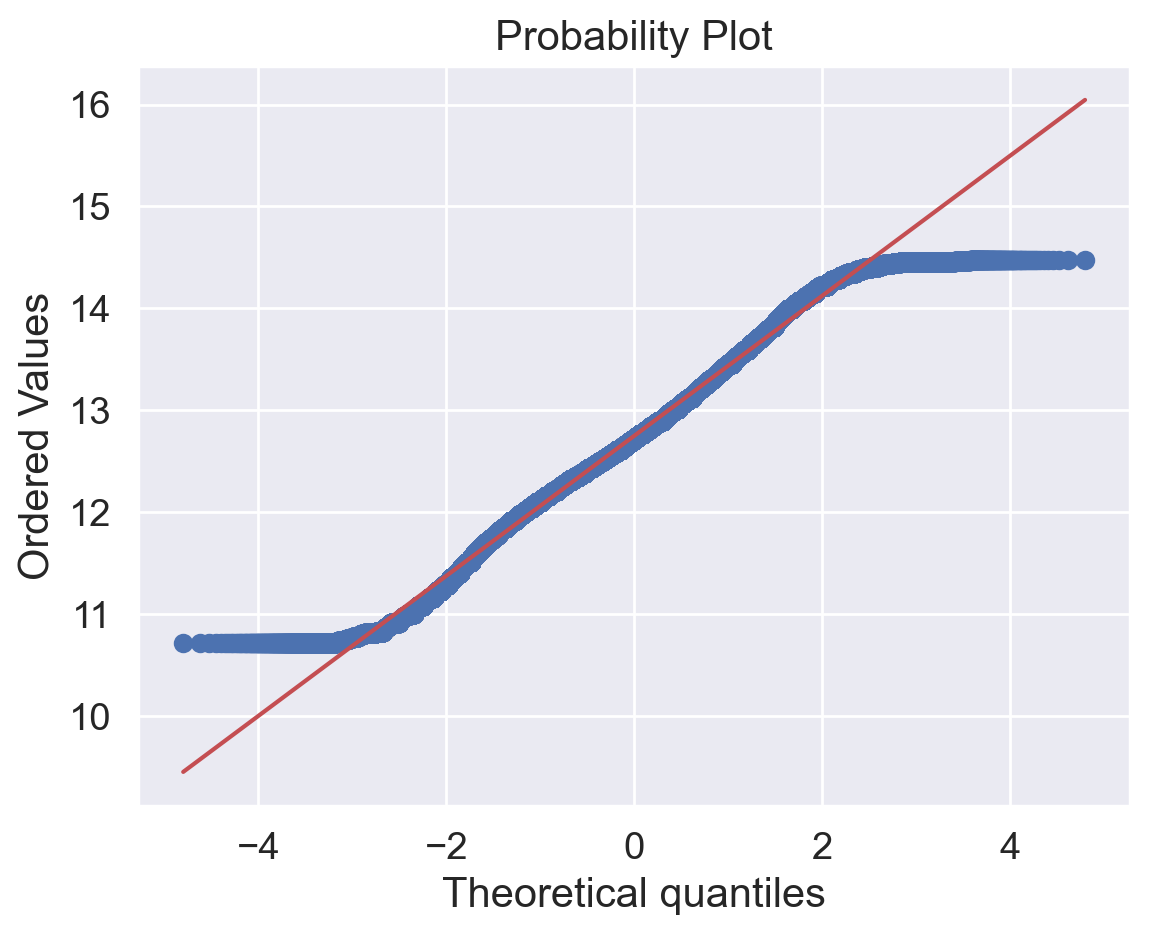

Skewness: 0.038228
Kurtosis: 0.041969


In [188]:
sns.distplot(data['target'], fit=norm);

# Get the fitted parameters used by the function
(mu, sigma) = norm.fit(data['target'])
print( '\n mu = {:.2f} and sigma = {:.2f}\n'.format(mu, sigma))
plt.legend(['Normal dist. ($\mu=$ {:.2f} and $\sigma=$ {:.2f} )'.format(mu, sigma)],
            loc='best')
plt.ylabel('Frequency')
plt.title('Target variable distribution')

fig = plt.figure()
res = stats.probplot(data['target'], plot=plt)
plt.show()

print("Skewness: %f" % data['target'].skew())
print("Kurtosis: %f" % data['target'].kurt())

In [197]:
numeric_feats = ['baths', 'beds', 'stories', 'parking slots', 'sqft', 'lotsize', 'average_household_size',
                 'Year built', 'Remodeled year', 'nearest_school_distance', 'nearest_school_rating',
                 'median_age', 'total_population', 'foreign_born', 'number_of_veterans']

skewed_feats = data[numeric_feats].apply(lambda x: skew(x)).sort_values(ascending=False)
skewness = pd.DataFrame({'Skewed Features' :skewed_feats})
skewness.head(10)

,Skewed Features
foreign_born,4.522646
nearest_school_distance,4.076267
total_population,2.891916
parking slots,2.763296
baths,1.397401
average_household_size,1.395569
stories,1.390779
beds,1.205249
number_of_veterans,1.125196
sqft,0.925794


In [202]:
skewed_features = []
for feat in skewness.index:
    if abs(skewness.loc[feat, 'Skewed Features']) > 0.75:
        print(feat)
        skewed_features.append(feat)

foreign_born
nearest_school_distance
total_population
parking slots
baths
average_household_size
stories
beds
number_of_veterans
sqft
Year built
Remodeled year


In [203]:
from scipy.special import boxcox1p
for feat in skewed_features:
    data[feat] = boxcox1p(data[feat], 0.15)
    data[feat] += 1

In [204]:
x = data.drop(labels='target', axis=1)
y = data['target']
x_train, x_test, y_train, y_test = train_test_split(x, y)

model_baseline = GradientBoostingRegressor(random_state=42)
model_baseline.fit(x_train, y_train)

y_pred = model_baseline.predict(x_test)
s
print(mean_squared_error(y_test, y_pred))
print(r2_score(y_test, y_pred))

0.14842608995270923
0.6877925996075467
